# Dimensionality reduction for unpaired RNA / protein — PCA, PLS, autoencoders

**Python / Jupyter port of `analysis/dimensionality-reduction/dimensionality_reduction_wheat.qmd`.**

Author of the original R analysis: Kristina Gagalova.

---

## What this notebook is

This is a **line-for-line re-implementation in Python** of the R/Quarto notebook of the
same name. The scientific question, the experimental design, the diagnostics (D1–D11) and
the decision rules are unchanged. What changed is the *machinery*:

| In the R notebook | Here |
|:---|:---|
| Adam optimiser written out by hand (`adam_init` / `adam_update`) | `torch.optim.Adam` |
| Autoencoder forward pass **and hand-derived gradients** | `torch.nn` + autograd |
| PLS2 NIPALS written out by hand (`pls2`, `pls_predict`) | `sklearn.cross_decomposition.PLSRegression` |
| Ridge normal equations written out by hand (`ridge_fit`) | `sklearn.linear_model.Ridge` |
| PCA by explicit `svd()` + manual projection | `sklearn.decomposition.PCA` |
| Subspace cosines via manual `qr()` / `svd()` | `scipy.linalg.subspace_angles` |
| `η²` via `summary(aov(...))[[1]]` sum-of-squares arithmetic | `pingouin.anova(..., effsize="np2")` |
| Leave-one-condition-out fold construction by index arithmetic | `sklearn.model_selection.LeaveOneGroupOut` |
| DESeq2 `vst()` (Bioconductor, via R) | `pydeseq2` `DeseqDataSet.vst()` |
| `impute::impute.knn` (Bioconductor) | `sklearn.impute.KNNImputer` |
| mean baseline written out by hand | `sklearn.dummy.DummyRegressor` |

**The point of the rewrite is legibility.** The R version implemented every model from
scratch, deliberately, so the update rules were auditable. That is a defensible choice, but
it means a reader has to verify ~400 lines of hand-derived gradient algebra before they can
trust a single number. Here each model is a call into a package that is peer-reviewed,
heavily used, and independently tested — so the reader can spend their attention on the
*experimental design and the validation logic*, which is where the actual scientific risk
lives.

One genuine correctness benefit came free: the R VAE's gradients were derived by hand
(`dmu`, `dlv` in `ae_fit`). Here they come from autograd, so that whole class of error is
gone.

## The question

> Given 8 experimental conditions and unpaired RNA / protein layers, which
> dimensionality-reduction method is actually justified — and does any of them beat simply
> predicting the mean?

Candidates: PCA, PLS, three autoencoder variants (linear, non-linear, variational), plus a
condition-aligned autoencoder matching the architecture of `rnaprot/unpaired.py`
(`ConditionAlignedAE`) in the project's existing Python work on this server.

## The design, and why it constrains everything

- 2 varieties (Cadenza, Norin), analysed **separately** throughout.
- 2 treatments (`T0` = uninfected control, `T1` = infected) × 4 timepoints (0/24/48/72 hpi)
  = **8 design cells**, 3 replicates each = 24 samples per layer.
- **Unpaired ("Case B")**: RNA plant *i* and protein plant *i* are *not* the same plant. The
  design cell is the **only** axis that links the two layers. Every cross-layer method below
  respects that.
- Thousands of features against 24 samples. Parameters vastly outnumber observations, so
  **out-of-sample validation is the only meaningful evidence** and in-sample fit is worthless.

---

## Package choices, and why these ones

Every non-trivial computation below is delegated to a package that is either **published and
peer-reviewed** or is a de-facto community standard with very wide use. Nothing statistical
is hand-rolled unless there is no packaged equivalent.

| Task | Package | Provenance |
|:---|:---|:---|
| Arrays, linear algebra | **NumPy** | Harris *et al.* (2020) *Nature* 585:357 |
| Data frames | **pandas** | McKinney (2010) *Proc. SciPy* |
| Scientific routines (`subspace_angles`, stats) | **SciPy** | Virtanen *et al.* (2020) *Nature Methods* 17:261 |
| PCA, PLS, ridge, kNN imputation, CV splitters, dummy baseline | **scikit-learn** | Pedregosa *et al.* (2011) *JMLR* 12:2825 |
| RNA-seq variance-stabilising transform (DESeq2 port) | **PyDESeq2** | Muzellec *et al.* (2023) *Bioinformatics* 39:btad547 |
| Autoencoders, VAE, Adam, autograd | **PyTorch** | Paszke *et al.* (2019) *NeurIPS* 32 |
| ANOVA effect sizes (η²) | **pingouin** | Vallat (2018) *JOSS* 3:1026 |
| Linear models / design matrices | **statsmodels**, **formulaic** | Seabold & Perktold (2010) *Proc. SciPy* |
| Plots | **matplotlib**, **seaborn** | Hunter (2007) *CiSE* 9:90; Waskom (2021) *JOSS* 6:3021 |
| Embarrassingly-parallel loops | **joblib** | standard (scikit-learn's own backend) |
| Notebook format | **Jupyter** | Kluyver *et al.* (2016) *ELPUB* |

### Packages considered and rejected

- **`horns`** (PyPI) for Horn's parallel analysis (D1). Rejected: very few users, no
  publication, and it simulates *uncorrelated normal* data. The R notebook uses the
  **permutation** variant (Buja & Eyuboglu 1992) — permute each feature independently, so
  each feature's own marginal distribution is preserved and only the between-feature
  correlation is destroyed. That is ~5 lines on top of `sklearn.decomposition.PCA`, so it is
  written inline rather than taking a dependency on an unmaintained package.
- **`factor_analyzer`** — aimed at common factor analysis / rotation, not PCA component
  retention on a p ≫ n matrix. Wrong tool.
- **`mbpls` / `pyChemometrics`** for PLS. Rejected: scikit-learn's `PLSRegression` is the
  same NIPALS PLS2 algorithm, far more widely used and tested.
- **`keras` / `tensorflow`** for the autoencoders. PyTorch was chosen because the project's
  existing Python work on this server (`rnaprot/unpaired.py`) is already PyTorch, so the
  architectures stay directly comparable.

### The two small classes that *are* written here

There is no packaged equivalent for these, so they are defined explicitly and kept short:

1. `BlockScaler` — centre columns, then divide the whole block by one scalar (its RMS) so
   the block has unit total variance. This is *not* `StandardScaler`: per-feature
   z-scoring would destroy the relative variance structure between features, which is
   exactly what the high-variance feature selection upstream is trying to keep. It is
   written as a `sklearn` transformer (`fit`/`transform`) so it drops into `Pipeline`.
2. `AutoEncoder` / `ConditionAlignedAE` — `torch.nn.Module` subclasses. Defining the
   architecture is unavoidable; the optimiser, the gradients and the training loop are all
   PyTorch's.

---

## Analysis outline

Each diagnostic **D#** tests one assumption that the headline comparison rests on. The
decision rules were fixed before results were seen.

| Step | Diagnostic | What it asks | Why it matters |
|:---|:---|:---|:---|
| §1 | — | Setup, QC, normalisation, imputation | Shared upstream with the other notebooks |
| §2 | — | Methods and their assumptions | Each stated explicitly, with references |
| §3 | — | Implementation | Now: package calls, not hand-written algebra |
| §4 | **D1** | How many components are real? | Parallel analysis vs a permutation null |
| §5 | **D2** | Do components track the design? | Structure must be interpretable |
| §6 | **D3** | Is a linear AE ≡ PCA? | Baldi–Hornik: a correctness check on the code |
| §7 | **D4** | Does any method beat the mean? | **The headline comparison**, leave-one-condition-out |
| §7a | **D4-null** | Is D4's Q² reachable by chance? | Permutation null on every method |
| §7b | **D7** | Condition means or replicate pairing? | Aggregated (n=8) vs sample-level (n=24) |
| §7c | **D8** | Does global feature selection leak? | Global vs in-fold RNA selection |
| §7d | **D9** | Sample-level condition-aligned AE | The real test of centroid alignment |
| §8 | **D5** | Are we sample-limited? | Learning curve |
| §9 | **D6** | Are latent spaces stable? | Seed-to-seed reproducibility |
| §9b | **D11** | Why does Cadenza beat Norin? | t0-exclusion test + RNA effect sizes |
| §10 | — | Assumption validation summary | |
| §11 | — | What is safe to claim | |
| §12 | — | **Agreement with the R implementation** | Port validation, table by table |

### The one methodological trap this notebook is built around

The R version went through peer review, which found a **cross-validation centring leak**.
It is worth stating up front because it dictates the shape of most of the code below.

If you centre the full 8-condition matrix *before* splitting off a held-out condition, then
once column means are zero the held-out row is an **exact linear combination of the training
rows**:

$$x_i = -\sum_{j \neq i} x_j$$

For any *homogeneous* (no-intercept) linear predictor — which is exactly what the
condition-aligned AE is, `dec_p(enc_r(x))` with no bias — this forces
$\hat{y}(x_i) = -\sum_j \hat{y}(x_j)$ **by algebra alone**, independent of whether the model
learned anything. The result: an inflated Q² that looks like signal.

The fix, applied to every train/test analysis below (D4, D7, D8, D9, D11a): centring and
scaling are **fitted on training-fold rows only** and then applied to the held-out row.
Analyses with no train/test split (D1, D2, D3, D6, D11b) are unaffected and use the
globally-scaled blocks.

In this Python version that discipline is enforced structurally: the fold-safe blocks are
the `*_raw` attributes, and every CV loop passes them through a `BlockScaler` that is
`fit()` inside the fold.

---

# 1. Setup

## 1.0 Imports and global configuration

In [1]:
# --- standard library -------------------------------------------------------
import itertools
import os
import sys
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

# --- numerics / data --------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.linalg import subspace_angles          # principal angles between subspaces

# --- statistics -------------------------------------------------------------
import pingouin as pg                             # ANOVA effect sizes (eta-squared)
from formulaic import model_matrix                # R-style formula -> design matrix

# --- machine learning -------------------------------------------------------
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline

# --- deep learning ----------------------------------------------------------
import torch
import torch.nn as nn

# --- RNA-seq ----------------------------------------------------------------
from pydeseq2.dds import DeseqDataSet

# --- plotting / parallelism -------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
SEED = 20260823                  # same master seed as the R notebook
RNG  = np.random.default_rng(SEED)

PROJECT = Path("/mnt/integrated-omics/IntegrateProtRNA")
DATA    = PROJECT / "data" / "real"

# Torch: one thread per process. Every model here is tiny (8 x 2000), so intra-op
# threading is pure overhead -- and it would fight with joblib for cores during
# the permutation nulls.
torch.set_num_threads(1)
DTYPE = torch.float64            # float64 keeps numerical parity with R

N_JOBS = min(32, os.cpu_count())  # joblib workers for the permutation nulls

# Same three-colour scheme as the R notebook, so figures compare side by side.
sns.set_theme(style="whitegrid", context="notebook")
BLUE, RED, GREEN, GREY = "#2C6FBB", "#D1495B", "#4C9F70", "#7F7F7F"
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.titlesize": 11, "axes.labelsize": 10})

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import sklearn, scipy, matplotlib, seaborn, pydeseq2, joblib, formulaic
print(f"{'python':12s} {sys.version.split()[0]}")
for m in (np, pd, scipy, sklearn, torch, pydeseq2, pg, formulaic,
          matplotlib, seaborn, joblib):
    print(f"{m.__name__:12s} {m.__version__}")
print(f"{'cpus':12s} {os.cpu_count()}  (joblib n_jobs={N_JOBS})")

python       3.10.12
numpy        2.2.6
pandas       2.3.3
scipy        1.15.3
sklearn      1.7.2
torch        2.13.0+cu130
pydeseq2     0.5.2
pingouin     0.6.1
formulaic    1.2.2
matplotlib   3.10.9
seaborn      0.13.2
joblib       1.5.3
cpus         32  (joblib n_jobs=32)


## 1.1 The experimental design

These constants encode what the RNA-seq sample sheet confirms. They are written out
explicitly rather than inferred from the data, so a mislabelled file fails loudly instead of
silently redefining the design.

- `T0` = **NEG**, uninfected control — the reference level.
- `T1` = **PN143**, infected.
- `t0..t3` in the metadata = **0 / 24 / 48 / 72 hours post inoculation**.

The **design cell** (`treatment_ttime`, e.g. `T1_t48`) is the unit that links the RNA and
protein layers. Under the unpaired design it is the *only* shared axis.

In [2]:
TREATMENTS = ["T0", "T1"]                 # T0 = control (reference), T1 = infected
TIMEPOINTS = [0, 24, 48, 72]              # hours post inoculation
N_REPS     = 3

# Cell ordering matches the R notebook exactly: all timepoints of T0, then all of T1.
CELLS = [f"{tr}_t{t}" for tr in TREATMENTS for t in TIMEPOINTS]

VARIETY_FILES = {"Cadenza": "cadenza", "Norin": "norin"}

print(f"{len(CELLS)} design cells x {N_REPS} replicates "
      f"= {len(CELLS) * N_REPS} samples per layer")
print(CELLS)

8 design cells x 3 replicates = 24 samples per layer
['T0_t0', 'T0_t24', 'T0_t48', 'T0_t72', 'T1_t0', 'T1_t24', 'T1_t48', 'T1_t72']


## 1.2 Loading one variety

Reads the three files per variety and builds the metadata columns the rest of the notebook
relies on (`time_num`, `time_f`, `cell`).

The sample IDs (`LH4`, `LH5`, …) coincide between the RNA and protein matrices because both
trace back to the same field-plot label. **This is not treated as sample-level pairing
anywhere downstream** — under the Case B design only design-cell membership links the
layers. D7 (§7b) tests directly what happens if you *do* trust that label, and finds it is
not safe.

In [3]:
def load_variety(prefix):
    '''Load one variety's metadata, RNA counts and protein intensities.

    Returns
    -------
    meta : DataFrame  samples x design columns (index = sample id)
    rna  : DataFrame  genes x samples, raw counts
    prot : DataFrame  proteins x samples, raw LFQ intensities (0 = not quantified)
    '''
    meta = pd.read_csv(DATA / f"{prefix}_metadata.csv", index_col=0)

    # metadata stores timepoints as codes t0..t3; map them onto real hours
    codes = sorted(meta["timepoint"].unique())
    assert len(codes) == len(TIMEPOINTS), f"expected {len(TIMEPOINTS)} timepoints, got {codes}"
    meta["time_num"] = meta["timepoint"].map(dict(zip(codes, TIMEPOINTS)))

    # ordered categoricals, so factor level order is deterministic (as in R)
    meta["treatment"] = pd.Categorical(meta["treatment"], categories=TREATMENTS)
    meta["time_f"]    = pd.Categorical(meta["time_num"],  categories=TIMEPOINTS)
    meta["cell"]      = pd.Categorical(
        meta["treatment"].astype(str) + "_t" + meta["time_num"].astype(str),
        categories=CELLS,
    )

    rna  = pd.read_csv(DATA / f"{prefix}-rnaseq.csv", index_col=0)
    prot = pd.read_csv(DATA / f"{prefix}-prot.csv",   index_col=0)

    # fail loudly if a layer carries a sample the sample sheet does not know about
    assert set(rna.columns)  <= set(meta.index), "RNA columns not in metadata"
    assert set(prot.columns) <= set(meta.index), "protein columns not in metadata"

    # reorder both layers to metadata order, so column i means the same thing everywhere
    return meta, rna[meta.index], prot[meta.index]


_meta, _rna, _prot = load_variety("cadenza")
print("Cadenza -- metadata head:")
display(_meta.head(6))
print(f"RNA counts   : {_rna.shape[0]:>7,} genes    x {_rna.shape[1]} samples")
print(f"Protein LFQ  : {_prot.shape[0]:>7,} proteins x {_prot.shape[1]} samples")
print(f"cells x reps : {dict(_meta.groupby('cell', observed=False).size())}")

Cadenza -- metadata head:

,variety,treatment,timepoint,replicate,time_num,time_f,cell
LH4,V1,T0,t0,r0,0,0,T0_t0
LH5,V1,T0,t0,r1,0,0,T0_t0
LH6,V1,T0,t0,r2,0,0,T0_t0
LH10,V1,T1,t0,r0,0,0,T1_t0
LH11,V1,T1,t0,r1,0,0,T1_t0
LH12,V1,T1,t0,r2,0,0,T1_t0


RNA counts   : 128,544 genes    x 24 samples
Protein LFQ  :   6,105 proteins x 24 samples
cells x reps : {'T0_t0': np.int64(3), 'T0_t24': np.int64(3), 'T0_t48': np.int64(3), 'T0_t72': np.int64(3), 'T1_t0': np.int64(3), 'T1_t24': np.int64(3), 'T1_t48': np.int64(3), 'T1_t72': np.int64(3)}


## 1.3 RNA QC: low-expression filter, then the variance-stabilising transform

Two steps, in order.

**1. Low-expression filter.** Keep a gene if it has at least `min_count = 10` reads in at
least `N_REPS = 3` samples. This is the DESeq2-style rule (≥ *min_count* in at least as many
samples as the smallest design group), *not* `edgeR::filterByExpr`'s adaptive heuristic. It
is more permissive, and it is the criterion the project's standalone limma workflow uses, so
gene sets stay comparable across notebooks.

**2. VST** (variance-stabilising transform) via **PyDESeq2**, the peer-reviewed Python port
of DESeq2. Raw counts are heteroscedastic — variance grows with the mean — which would make
every variance-based method below (PCA, high-variance feature selection, PLS) simply rank
genes by expression level. VST removes that mean–variance coupling.

`use_design=False` is PyDESeq2's equivalent of DESeq2's `blind=TRUE`: dispersions are fitted
with an intercept-only model, so the transform does **not** see the treatment/timepoint
labels. That matters here because the transformed matrix is fed straight into unsupervised
methods and into cross-validation — a design-aware transform would leak the very structure
D2 and D4 are trying to measure.

In [4]:
def qc_rna(counts, meta, min_count=10, n_reps=N_REPS, n_cpus=8):
    '''Filter low-expression genes, then variance-stabilise with PyDESeq2.

    Returns (filtered_counts, vst) — both genes x samples.
    '''
    keep = (counts >= min_count).sum(axis=1) >= n_reps
    cf   = counts.loc[keep]

    # PyDESeq2 wants samples x genes, and integer counts.
    dds = DeseqDataSet(
        counts=cf.T.astype(int),
        metadata=meta[["cell"]].astype(str),
        design="~cell",          # recorded on the object; NOT used by a blind VST
        quiet=True,
        n_cpus=n_cpus,
    )
    dds.vst(use_design=False)    # == DESeq2::vst(blind = TRUE)

    vst = pd.DataFrame(dds.layers["vst_counts"].T, index=cf.index, columns=cf.columns)
    return cf, vst

## 1.4 Protein QC

Three conventions, each of which is a modelling decision rather than a formality:

1. **Zero means "not quantified", not "absent".** Standard LFQ convention. Zeros become `NaN`
   so they are handled by the missingness model in §1.5 instead of being averaged in as real
   low values.
2. **`log2`**, to put protein intensities on the same additive scale as VST'd RNA.
3. **Validity filter:** keep a protein with ≥ 2 valid values in **at least one** design cell.
   A global "≥ 50% valid" rule would delete genuine on/off biology — a protein induced only
   at 72 hpi is 75% missing by design, and is exactly the kind of protein this experiment
   exists to find.

Then **median normalisation**: shift each sample so its median matches the global median.
This corrects per-run loading differences, not biology.

*(No decoy / contaminant / unique-peptide filtering is possible — the supplied mapping files
carry no such columns.)*

In [5]:
def qc_prot(intensity, meta, min_valid_in_cell=2):
    '''Zero -> NaN, log2, validity filter, median normalisation.

    Returns a proteins x samples DataFrame, still containing NaN.
    '''
    m = np.log2(intensity.replace(0, np.nan))

    # count valid (non-missing) values per protein within each design cell
    valid = pd.DataFrame(
        {cl: m.loc[:, (meta["cell"] == cl).to_numpy()].notna().sum(axis=1) for cl in CELLS}
    )
    mf = m.loc[valid.max(axis=1) >= min_valid_in_cell]

    # median normalisation: per-sample shift onto the global median
    shift = mf.median(axis=0, skipna=True) - np.nanmedian(mf.to_numpy())
    return mf.sub(shift, axis=1)

## 1.5 Missingness: diagnose the mechanism, then impute accordingly

Imputing all missing protein values the same way is wrong, because they arise two different
ways:

- **MNAR** (missing not at random) — a protein missing in **every** replicate of a cell but
  seen elsewhere. That is not a measurement failure; it is genuinely low or absent in that
  condition. Imputing it with a neighbour-based estimate would *invent* signal. It gets a
  **left-censored draw**: Perseus-style down-shifted normal, mean − 1.8·SD, width 0.3·SD.
- **MAR** (missing at random) — missing in only **some** replicates of its cell. That is
  stochastic detection failure, and the other replicates carry information about the true
  value. It gets **k-nearest-neighbour imputation** (k = 10), via `sklearn.impute.KNNImputer`.

**A note on KNNImputer's orientation.** Bioconductor's `impute.knn` finds the *k nearest
genes* for a gene with missing values. `KNNImputer` finds the *k nearest rows*. So the matrix
is passed **proteins × samples** (proteins as rows), which makes the two equivalent. Passing
it transposed would silently do something else — impute from the nearest *samples* — and
still run without error.

In [6]:
def label_missingness(norm, meta):
    '''Label each cell of the matrix as "obs", "MAR" or "MNAR".

    MNAR: protein absent from EVERY replicate of that design cell.
    MAR : protein absent from some but not all replicates of that design cell.
    '''
    n_obs = pd.DataFrame(
        {cl: norm.loc[:, (meta["cell"] == cl).to_numpy()].notna().sum(axis=1) for cl in CELLS}
    )
    isna = norm.isna()
    lab  = pd.DataFrame("obs", index=norm.index, columns=norm.columns)

    for cl in CELLS:
        cols = norm.columns[(meta["cell"] == cl).to_numpy()]
        gone = n_obs[cl] == 0                                  # nothing seen in this cell
        lab.loc[gone, cols] = "MNAR"
        lab.loc[~gone, cols] = lab.loc[~gone, cols].where(~isna.loc[~gone, cols], "MAR")

    return lab.where(isna, "obs")                              # observed values stay "obs"


def impute_mixed(norm, meta, rng, downshift=1.8, width=0.3):
    '''Mechanism-specific imputation: kNN for MAR, down-shifted normal for MNAR.'''
    lab = label_missingness(norm, meta)

    # MAR: k-nearest-PROTEIN imputation (rows are proteins -- see the note above)
    mar = pd.DataFrame(
        KNNImputer(n_neighbors=10).fit_transform(norm.to_numpy()),
        index=norm.index, columns=norm.columns,
    )

    # MNAR: per-sample left-censored draw from the low tail of that sample
    mnar = norm.copy()
    for j in norm.columns:
        v, nas = norm[j], norm[j].isna()
        if nas.any():
            mnar.loc[nas, j] = rng.normal(v.mean() - downshift * v.std(),
                                          width * v.std(), int(nas.sum()))

    mixed = norm.mask(lab == "MAR", mar).mask(lab == "MNAR", mnar)
    assert not mixed.isna().any().any(), "imputation left NaNs behind"
    return mixed, lab

## 1.6 Run the upstream pipeline for both varieties

`prepare_variety` is the Python equivalent of `prepare_variety()` in `R/wheat_pipeline.R`,
minus the limma differential-expression step — this notebook never uses the DE results, only
the VST'd RNA matrix, the imputed protein matrix and the metadata.

Each variety gets its own seeded generator so the MNAR draws are reproducible and
independent between varieties.

In [7]:
@dataclass
class Variety:
    label: str
    meta:  pd.DataFrame
    vst:   pd.DataFrame      # genes    x samples, variance-stabilised RNA
    prot:  pd.DataFrame      # proteins x samples, imputed log2 intensities
    qc:    dict              # bookkeeping for the QC summary table


def prepare_variety(label, prefix, seed=1):
    rng = np.random.default_rng(seed)
    meta, rna, prot = load_variety(prefix)

    cf, vst   = qc_rna(rna, meta)
    pn        = qc_prot(prot, meta)
    mixed, lab = impute_mixed(pn, meta, rng)

    qc = dict(
        rna_in=rna.shape[0],   rna_kept=cf.shape[0],
        prot_in=prot.shape[0], prot_kept=pn.shape[0],
        prot_missing=float(pn.isna().to_numpy().mean()),
        mnar_frac=float((lab == "MNAR").to_numpy().mean()),
        mar_frac=float((lab == "MAR").to_numpy().mean()),
    )
    return Variety(label, meta, vst, mixed, qc)


VARIETIES = {
    name: prepare_variety(name, prefix, seed=1)
    for name, prefix in VARIETY_FILES.items()
}

qc_table = pd.DataFrame({v.label: v.qc for v in VARIETIES.values()}).T
qc_table = qc_table.astype({"rna_in": int, "rna_kept": int, "prot_in": int, "prot_kept": int})
print("Upstream QC summary")
display(qc_table.round(4))

Fit type used for VST : parametric


Fit type used for VST : parametric


Upstream QC summary


,rna_in,rna_kept,prot_in,prot_kept,prot_missing,mnar_frac,mar_frac
Cadenza,128544,59931,6105,5861,0.2234,0.1022,0.1211
Norin,145065,59502,5879,5641,0.2102,0.0862,0.1239


## 1.7 The analysis blocks

Two representations are built, and **the distinction is the whole design of the study**:

- **Sample level** (24 × p) — used for within-layer methods (PCA, the plain autoencoders).
  Each layer has its own 24 samples, and there is no claim that RNA sample *i* corresponds to
  protein sample *i*.
- **Condition level** (8 × p) — design-cell means, used for anything that **crosses** the two
  layers. Under the unpaired design the condition is the only shared axis.

Features are reduced to the top **2000 RNA** / **1000 protein** most-variable rows. That is
not for speed — it is because unsupervised variance-based methods on 60,000 genes are
dominated by the long tail of near-constant genes.

### Two families of fields, and which analyses may use which

| Fields | Scaling | Safe for |
|:---|:---|:---|
| `R_samp`, `P_samp`, `R_cond`, `P_cond` | centred + scaled using **all 8 conditions** | analyses with **no** train/test split: D1, D2, D3, D6, D11b |
| `R_samp_raw`, `P_samp_raw`, `R_cond_raw`, `P_cond_raw` | **untouched** | every analysis that holds out a condition: D4, D7, D8, D9, D11a — these must scale from **training rows only**, inside the fold |

This is the structural fix for the centring leak described in the outline. Using a
pre-scaled block inside a CV loop is the bug; keeping the two families separate and named
makes that bug visible rather than silent.

In [8]:
def top_variable(mat, n):
    '''Row indices of the n most variable rows (features x samples matrix).'''
    return mat.var(axis=1).nlargest(n).index


def cell_means(mat, meta):
    '''features x samples -> features x design cells (the Case B pseudo-samples).'''
    return mat.T.groupby(meta["cell"], observed=False).mean().T


class BlockScaler(BaseEstimator, TransformerMixin):
    '''Centre each column, then divide the WHOLE block by one scalar (its RMS).

    After `transform`, sum(M**2) / n_rows == 1, i.e. the block carries unit total
    variance. Two blocks scaled this way contribute equally to a joint loss, so
    neither RNA (more features, wider dynamic range) nor protein dominates.

    Deliberately NOT StandardScaler: per-feature z-scoring would flatten the
    between-feature variance structure that the high-variance selection above
    exists to preserve, and would amplify near-constant features into noise.
    '''

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.mean_  = X.mean(axis=0)
        self.scale_ = np.sqrt(((X - self.mean_) ** 2).sum() / X.shape[0])
        return self

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean_) / self.scale_

In [9]:
@dataclass
class Blocks:
    '''Analysis matrices for one variety. Rows are observations, columns features.'''
    label: str
    # globally scaled -- ONLY for analyses with no train/test split
    R_samp: pd.DataFrame
    P_samp: pd.DataFrame
    R_cond: pd.DataFrame
    P_cond: pd.DataFrame
    # untouched -- for every analysis that holds out a condition
    R_samp_raw: pd.DataFrame
    P_samp_raw: pd.DataFrame
    R_cond_raw: pd.DataFrame
    P_cond_raw: pd.DataFrame
    cond: pd.DataFrame       # 8 x {cell, treatment, time_f}
    meta: pd.DataFrame


def make_blocks(v, n_rna=2000, n_prot=1000):
    hv_r = top_variable(v.vst,  n_rna)
    hv_p = top_variable(v.prot, n_prot)

    # .T : features x samples  ->  samples x features (observations as rows)
    R_samp = v.vst.loc[hv_r].T
    P_samp = v.prot.loc[hv_p].T
    R_cond = cell_means(v.vst.loc[hv_r],  v.meta).T
    P_cond = cell_means(v.prot.loc[hv_p], v.meta).T

    def scaled(M):
        return pd.DataFrame(BlockScaler().fit_transform(M), index=M.index, columns=M.columns)

    cond = pd.DataFrame({
        "cell":      list(R_cond.index),
        "treatment": pd.Categorical([c.split("_t")[0] for c in R_cond.index],
                                    categories=TREATMENTS),
        "time_f":    pd.Categorical([int(c.split("_t")[1]) for c in R_cond.index],
                                    categories=TIMEPOINTS),
    }).set_index("cell", drop=False)

    return Blocks(
        label=v.label,
        R_samp=scaled(R_samp), P_samp=scaled(P_samp),
        R_cond=scaled(R_cond), P_cond=scaled(P_cond),
        R_samp_raw=R_samp, P_samp_raw=P_samp,
        R_cond_raw=R_cond, P_cond_raw=P_cond,
        cond=cond, meta=v.meta,
    )


BLOCKS = {name: make_blocks(v) for name, v in VARIETIES.items()}

display(pd.DataFrame([
    dict(variety=b.label,
         rna_samples=b.R_samp.shape[0],  rna_features=b.R_samp.shape[1],
         prot_samples=b.P_samp.shape[0], prot_features=b.P_samp.shape[1],
         conditions=b.R_cond.shape[0])
    for b in BLOCKS.values()
]).set_index("variety"))

# sanity check: the scaled blocks really do carry unit total variance
for name, b in BLOCKS.items():
    for fld in ("R_samp", "P_samp", "R_cond", "P_cond"):
        M = getattr(b, fld).to_numpy()
        assert np.isclose((M ** 2).sum() / M.shape[0], 1.0), (name, fld)
print("scaled blocks: unit total variance confirmed")

,rna_samples,rna_features,prot_samples,prot_features,conditions
variety,,,,,
Cadenza,24,2000,24,1000,8
Norin,24,2000,24,1000,8


scaled blocks: unit total variance confirmed


> **The shape of this problem, stated plainly.** Thousands of features against 24 samples
> (8 conditions). Every method below operates where the number of parameters vastly exceeds
> the number of observations. That is not a reason to avoid dimensionality reduction — it is
> the reason to *use* it — but it does mean out-of-sample validation is the only meaningful
> evidence, and in-sample fit is worthless.

---

# 2. The methods, and what each one assumes

Nothing below is a black box being tried "to see what happens". Each method makes concrete
assumptions, and the diagnostics D1–D11 exist to test them.

## PCA

Finds orthogonal directions of maximum variance. **Unsupervised**: it never sees the protein
block or the design.

**Assumes:** structure is linear; variance is a proxy for signal; components are orthogonal;
the leading directions are the interesting ones. The last two are *conventions, not facts
about biology* — a low-variance direction can carry the biology, and biological programmes
are under no obligation to be orthogonal (Jolliffe & Cadima 2016).

→ tested by **D1** (are the leading components more than noise?) and **D2** (do they track
the design?).

## PLS

Finds directions in RNA that maximally covary with protein. Two-block and **supervised by the
second block**.

**Assumes:** linearity; that cross-block covariance is the right target; and — critically —
that the model is validated **out of sample**. At 8 conditions and thousands of features a
PLS component can be steered onto almost any target: in-sample cross-block correlation
reaches r ≈ 0.72 on *permuted* data in this very dataset. Cross-validated Q² against a
permutation null is the accepted remedy (Westerhuis *et al.* 2008).

→ tested by **D4** and the **D4 permutation null**.

## Autoencoders (linear, non-linear, variational)

An encoder compresses to a latent space, a decoder reconstructs. The variational form adds a
probabilistic latent with a KL penalty toward a standard normal prior (Kingma & Welling
2014).

**Assumes:** enough samples to fit the encoder/decoder weights. This is the binding
constraint here, and it is worth being precise about why.

A **linear** autoencoder is not an alternative to PCA — *it recovers the same subspace*.
Baldi & Hornik (1989) proved that the squared-error loss of a linear autoencoder has no local
minima and that its global optimum spans the principal subspace. **D3** verifies this
numerically, which doubles as a correctness check on the implementation.

The consequence is sharp: a VAE can only add value through **non-linearity** and the
**probabilistic prior**. Both cost parameters, and parameters need samples. Successful omics
VAEs operate on thousands of observations (single-cell data, where each *cell* is a sample)
or transfer from large reference cohorts. Bulk designs with tens of samples are a different
regime, and overfitting is the documented failure mode.

→ tested by **D3** (is the linear AE just PCA?), **D4** (does non-linearity buy anything out
of sample?) and **D6** (is the latent space even reproducible?).

## Condition-aligned autoencoder

The architecture of `ConditionAlignedAE` in `rnaprot/unpaired.py`: separate encoders per
modality, with the latent spaces tied by matching **condition centroids** rather than by
pairing samples. This is the structurally correct response to unpaired data — it never
assumes RNA sample *i* corresponds to protein sample *i*.

**Assumes:** all of the above, plus that condition centroids estimated from 3 replicates are
stable enough to align on.

→ tested by **D4** (condition level) and **D9** (sample level, where the centroid actually
averages 3 replicates and the assumption is genuinely exercised).

---

# 3. Implementation

Everything in this section is either a package call or a short, explicit model definition.

## 3.1 The autoencoders

Three variants, differing **only** in the encoder. The decoder is linear throughout, which is
what isolates the question *"does non-linearity buy anything?"* from every other design
choice:

| `kind` | encoder | latent |
|:---|:---|:---|
| `"linear"` | `z = W₁x + b₁` | spans the PCA subspace (Baldi–Hornik) |
| `"tanh"` | `z = tanh(W₁x + b₁)` | non-linear encoder |
| `"vae"` | `μ = W₁x + b₁`, `log σ² = W_v x + b_v`, `z = μ + σ⊙ε` | probabilistic, + KL penalty |

**What PyTorch buys us here.** The R version derived the gradients by hand — including the
VAE's reparameterisation-trick gradients `dμ` and `dlogvar`. That is roughly 40 lines of
error-prone calculus that a reader has to verify before trusting any VAE number. Here
`loss.backward()` does it, and `torch.optim.Adam` is the same Adam the R version wrote out
manually. The architecture below is the only thing left to check.

In [10]:
class AutoEncoder(nn.Module):
    '''Single-block autoencoder: linear, tanh, or variational.

    The decoder is always linear, so `kind` changes exactly one thing:
    whether (and how) the encoder is non-linear / stochastic.
    '''

    def __init__(self, p, k, kind="linear"):
        super().__init__()
        assert kind in ("linear", "tanh", "vae")
        self.kind = kind
        self.enc = nn.Linear(p, k)                                    # mu head for the VAE
        self.dec = nn.Linear(k, p)
        self.enc_logvar = nn.Linear(p, k) if kind == "vae" else None

    def encode(self, x):
        '''Deterministic latent code. The VAE uses its MEAN at test time.'''
        a = self.enc(x)
        return torch.tanh(a) if self.kind == "tanh" else a

    def forward(self, x):
        a = self.enc(x)
        if self.kind == "vae":
            logvar = self.enc_logvar(x).clamp(-10, 10)                # numerical guard
            z  = a + torch.exp(0.5 * logvar) * torch.randn_like(a)    # reparameterisation
            kl = -0.5 * torch.sum(1 + logvar - a ** 2 - logvar.exp()) / x.numel()
        else:
            z  = torch.tanh(a) if self.kind == "tanh" else a
            kl = torch.zeros((), dtype=x.dtype)
        return self.dec(z), kl


def fit_autoencoder(X, k=3, kind="linear", epochs=4000, lr=0.01, beta=1.0, seed=1):
    '''Train an AutoEncoder with Adam. Returns (model, loss_history).'''
    torch.manual_seed(seed)
    x = torch.as_tensor(np.asarray(X, dtype=float), dtype=DTYPE)

    model = AutoEncoder(x.shape[1], k, kind).to(DTYPE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    hist  = np.empty(epochs)

    for e in range(epochs):
        opt.zero_grad()
        xhat, kl = model(x)
        loss = torch.mean((xhat - x) ** 2) + beta * kl   # recon MSE + beta * KL
        loss.backward()
        opt.step()
        hist[e] = loss.item()

    return model, hist


@torch.no_grad()
def ae_encode(model, X):
    '''Latent scores for new rows, as a plain numpy array.'''
    x = torch.as_tensor(np.asarray(X, dtype=float), dtype=DTYPE)
    return model.encode(x).numpy()


@torch.no_grad()
def ae_reconstruct(model, X):
    x = torch.as_tensor(np.asarray(X, dtype=float), dtype=DTYPE)
    return model.dec(model.encode(x)).numpy()

## 3.2 The condition-aligned autoencoder

After `ConditionAlignedAE` in `rnaprot/unpaired.py`. Two encoders and two decoders, tied by
**condition centroids** — never by sample pairing, which does not exist in this design.

Four loss terms, with the same default weights as the Python module it mirrors
(`w = 0.5, 0.5, 2.0, 0.5`):

| term | weight | meaning |
|:---|:---|:---|
| `MSE(dec_r(enc_r(R)), R)` | `w₁ = 0.5` | RNA reconstruction |
| `MSE(dec_p(enc_p(P)), P)` | `w₂ = 0.5` | protein reconstruction |
| `MSE(dec_p(centroid_c z_r), centroid_c P)` | `w₃ = 2.0` | **cross-modal**: predict a condition's protein profile from its RNA latent |
| `MSE(centroid_c z_r, centroid_c z_p)` | `w₄ = 0.5` | **latent alignment**: the two modalities' condition centroids should coincide |

**Why linear here.** The version in `unpaired.py` uses MLP encoders (64 → 16, SiLU, dropout
0.1). This one is linear, and *that choice is itself part of the finding*: with 8 conditions,
even a linear map already has far more parameters than observations. If the linear version
cannot beat the mean baseline out of sample, a deeper one with strictly more parameters on
the same data will not either. D4 tests exactly that.

**Implementation note — centroids as a matrix product.** Rather than looping over conditions
(as the R version does, accumulating gradients by hand), group means are computed by
left-multiplying with a fixed averaging matrix `A` where `A[c, i] = 1/n_c` if row *i* belongs
to condition *c*. So `A @ z` *is* the stack of condition centroids, in one differentiable
operation. This is why the whole loss is 8 lines rather than 40.

**No biases.** Matching the R implementation, the encoders and decoders are homogeneous
linear maps. This is precisely the property that made the centring leak dangerous — see the
outline — which is why every fold below re-fits its scaler on training rows only.

In [11]:
def averaging_matrix(groups, levels, dtype=DTYPE):
    '''Rows-to-group-means matrix A: (n_groups x n_rows), A[c, i] = 1/n_c if row i is in c.

    Then `A @ Z` is the stack of group centroids -- one differentiable operation
    instead of a Python loop over conditions.
    '''
    groups = np.asarray(groups)
    A = np.zeros((len(levels), len(groups)))
    for c, lev in enumerate(levels):
        idx = np.flatnonzero(groups == lev)
        assert len(idx) > 0, f"no rows for group {lev}"
        A[c, idx] = 1.0 / len(idx)
    return torch.as_tensor(A, dtype=dtype)


class ConditionAlignedAE(nn.Module):
    '''Two linear encoder/decoder pairs, tied only through condition centroids.'''

    def __init__(self, p_r, p_p, k):
        super().__init__()
        self.enc_r = nn.Linear(p_r, k, bias=False)
        self.dec_r = nn.Linear(k, p_r, bias=False)
        self.enc_p = nn.Linear(p_p, k, bias=False)
        self.dec_p = nn.Linear(k, p_p, bias=False)

    def predict_protein(self, R):
        '''Cross-modal prediction: RNA in, protein out.'''
        return self.dec_p(self.enc_r(R))


def fit_condition_ae(R, P, cond_r, cond_p, k=3, w=(0.5, 0.5, 2.0, 0.5),
                     epochs=3000, lr=0.01, seed=1):
    '''Train a ConditionAlignedAE. R and P may have DIFFERENT numbers of rows --
    they are linked only by the shared levels of cond_r / cond_p.
    '''
    torch.manual_seed(seed)
    r = torch.as_tensor(np.asarray(R, dtype=float), dtype=DTYPE)
    p = torch.as_tensor(np.asarray(P, dtype=float), dtype=DTYPE)

    shared = [c for c in CELLS if c in set(cond_r) & set(cond_p)]
    A_r = averaging_matrix(cond_r, shared)      # (n_cond x n_rna_rows)
    A_p = averaging_matrix(cond_p, shared)      # (n_cond x n_prot_rows)

    model = ConditionAlignedAE(r.shape[1], p.shape[1], k).to(DTYPE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    hist  = np.empty(epochs)

    for e in range(epochs):
        opt.zero_grad()
        z_r, z_p = model.enc_r(r), model.enc_p(p)

        L1 = torch.mean((model.dec_r(z_r) - r) ** 2)              # RNA reconstruction
        L2 = torch.mean((model.dec_p(z_p) - p) ** 2)              # protein reconstruction
        L3 = torch.mean((model.dec_p(A_r @ z_r) - A_p @ p) ** 2)  # cross-modal, per condition
        L4 = torch.mean((A_r @ z_r - A_p @ z_p) ** 2)             # latent centroid alignment

        loss = w[0] * L1 + w[1] * L2 + w[2] * L3 + w[3] * L4
        loss.backward()
        opt.step()
        hist[e] = loss.item()

    return model, hist


@torch.no_grad()
def cond_ae_predict(model, R):
    r = torch.as_tensor(np.asarray(R, dtype=float), dtype=DTYPE)
    return model.predict_protein(r).numpy()


@torch.no_grad()
def cond_ae_encode_r(model, R):
    r = torch.as_tensor(np.asarray(R, dtype=float), dtype=DTYPE)
    return model.enc_r(r).numpy()

## 3.3 The predictors

Every method below is a function with the same signature, so §7's cross-validation loop can
treat them interchangeably. Each one is two to four lines of scikit-learn — compare with the
R version, where `ridge_fit`, `pls2` and `pls_predict` were ~60 lines of hand-written linear
algebra.

| function | what it is | package call |
|:---|:---|:---|
| `pred_mean` | **the reference point.** Predict the training mean protein profile, ignoring RNA entirely | `DummyRegressor(strategy="mean")` |
| `pred_design` | ridge on additive `treatment + time_f` indicators — recovers the *design*, not cross-layer biology | `Ridge(alpha=5)` |
| `pred_pca_ridge` | unsupervised compression, then ridge | `Pipeline(PCA, Ridge)` |
| `pred_pls` | supervised cross-block compression | `PLSRegression(scale=False)` |
| `pred_ae_ridge` | autoencoder latent, then ridge | `torch` + `Ridge` |
| `pred_cond_ae` | condition-aligned AE, direct cross-modal prediction | `torch` |

Two details worth flagging:

- **`PLSRegression(scale=False)`.** scikit-learn scales each column to unit variance by
  default; the R `pls2` only centres. `scale=False` matches the R behaviour, and matters
  because the blocks have already been scaled as *blocks* (§1.7).
- **The AE latent is re-scaled before ridge.** A linear autoencoder's latent *scale* is a free
  gauge parameter — rescale `W₁` and `W₂` inversely and the reconstruction is unchanged —
  whereas PCA's scores carry a meaningful, variance-ordered scale. A single fixed ridge
  `alpha` would therefore regularise the two unequally *even when they span the identical
  subspace*. `BlockScaler` is fitted on the training latent block to remove that
  discrepancy. This was a peer-review finding on the R version.

In [12]:
def pred_mean(Xtr, Ytr, Xte, **kw):
    '''Baseline: the training-set mean protein profile. Ignores RNA completely.'''
    return DummyRegressor(strategy="mean").fit(Xtr, Ytr).predict(Xte)


def pred_design(Xtr, Ytr, Xte, Dtr=None, Dte=None, alpha=5, **kw):
    '''Ridge on the DESIGN indicators. Recovers the experiment, not cross-layer biology.'''
    return Ridge(alpha=alpha).fit(Dtr, Ytr).predict(Dte)


def pred_pca_ridge(Xtr, Ytr, Xte, k=2, alpha=10, **kw):
    '''Unsupervised compression of RNA, then ridge onto protein.'''
    k = max(1, min(k, Xtr.shape[0] - 1, Xtr.shape[1]))
    return make_pipeline(PCA(n_components=k), Ridge(alpha=alpha)).fit(Xtr, Ytr).predict(Xte)


def pred_pls(Xtr, Ytr, Xte, k=2, **kw):
    '''PLS2: directions in RNA that maximally covary with protein.'''
    k = max(1, min(k, Xtr.shape[0] - 2))
    return PLSRegression(n_components=k, scale=False).fit(Xtr, Ytr).predict(Xte)


def pred_ae_ridge(Xtr, Ytr, Xte, k=2, kind="linear", epochs=4000, lr=0.02,
                  seed=1, alpha=10, **kw):
    '''Autoencoder latent -> (train-fitted rescale) -> ridge onto protein.'''
    model, _ = fit_autoencoder(Xtr, k=k, kind=kind, epochs=epochs, lr=lr, seed=seed)
    Ztr, Zte = ae_encode(model, Xtr), ae_encode(model, Xte)
    sc = BlockScaler().fit(Ztr)                       # gauge fix, fitted on TRAIN only
    return Ridge(alpha=alpha).fit(sc.transform(Ztr), Ytr).predict(sc.transform(Zte))


def pred_cond_ae(Xtr, Ytr, Xte, cond_tr=None, k=2, epochs=3000, seed=1, **kw):
    '''Condition-aligned AE, predicting protein directly from RNA.'''
    model, _ = fit_condition_ae(Xtr, Ytr, cond_tr, cond_tr, k=k, epochs=epochs, seed=seed)
    return cond_ae_predict(model, Xte)

## 3.4 Fold-safe scaling, design matrices, and the permutation scheme

Three shared helpers.

**`fold_matrices`** is the single place where the centring leak is prevented. It takes the
**raw** blocks and a train/test index split, fits one `BlockScaler` per block on the
*training rows only*, and returns all four scaled matrices. Every CV loop in this notebook
goes through it — there is no other way to build a train/test pair, which is deliberate.

**`design_matrices`** builds R-style model matrices with `formulaic`, dropping the intercept
column (ridge supplies its own). Two versions:
- *additive* `~ treatment + time_f` — the weak design baseline;
- *interactive* `~ treatment * time_f` — the strong one, used to residualise in D4.

**`permute_y_by_cell`** reshuffles **which condition's protein data is matched to which
condition's RNA data**, while preserving group structure (1 row/cell for condition means, 3
rows/cell at sample level). This destroys the between-condition correspondence and nothing
else, which is exactly the null hypothesis "RNA carries no information about protein beyond
what the marginal distributions already give you" (Westerhuis *et al.* 2008).

In [13]:
def fold_matrices(X_raw, Y_raw, tr, te):
    '''Build a train/test pair with scalers fitted on TRAINING ROWS ONLY.

    This is the fix for the CV centring leak: scaling the full matrix before the
    split makes a held-out row an exact linear combination of the training rows,
    which flatters any no-intercept linear predictor for free.
    '''
    X_raw = np.asarray(X_raw, dtype=float)
    Y_raw = np.asarray(Y_raw, dtype=float)
    sx = BlockScaler().fit(X_raw[tr])
    sy = BlockScaler().fit(Y_raw[tr])
    return (sx.transform(X_raw[tr]), sx.transform(X_raw[te]),
            sy.transform(Y_raw[tr]), sy.transform(Y_raw[te]))


def design_matrices(cond):
    '''Additive and interactive design matrices for the 8 conditions (intercept dropped).'''
    add = model_matrix("~ treatment + time_f", cond).drop(columns=["Intercept"])
    inter = model_matrix("~ treatment * time_f", cond).drop(columns=["Intercept"])
    return add.to_numpy(dtype=float), inter.to_numpy(dtype=float)


def permute_y_by_cell(Y, cell_of, rng):
    '''Reshuffle which cell's Y rows accompany which cell's X rows.

    Group sizes and within-cell structure are preserved; only the between-cell
    correspondence is destroyed. This is the null for every permutation test below.
    '''
    Y = np.asarray(Y, dtype=float)
    cell_of = np.asarray(cell_of)
    cells = pd.unique(pd.Series(cell_of))
    mapping = dict(zip(cells, rng.permutation(cells)))

    out = np.empty_like(Y)
    for cl in cells:
        src = np.flatnonzero(cell_of == mapping[cl])
        dst = np.flatnonzero(cell_of == cl)
        out[dst] = Y[rng.permutation(src)]
    return out


def q2_from_press(press, tss):
    '''Q2 = 1 - PRESS/TSS. Q2 <= 0 means "no better than predicting the mean".'''
    return 1.0 - press / tss


# quick self-check that the design matrices are what we think they are
_add, _int = design_matrices(BLOCKS["Cadenza"].cond)
print(f"additive design    : {_add.shape}  (2 treatments + 4 timepoints - 2 refs = 4 columns)")
print(f"interactive design : {_int.shape}  (adds 3 treatment x time interaction columns)")

additive design    : (8, 4)  (2 treatments + 4 timepoints - 2 refs = 4 columns)
interactive design : (8, 7)  (adds 3 treatment x time interaction columns)


---

# 4. D1 — How many components are real?

**The assumption being tested:** that the leading components describe structure rather than
noise.

**The test.** Horn's parallel analysis, in its **permutation** form (Horn 1965; Buja &
Eyuboglu 1992). Permute each feature independently — this destroys between-feature
correlation while preserving each feature's own marginal distribution exactly — recompute the
eigenvalue spectrum, and keep only components whose observed eigenvalue exceeds the permuted
95th percentile.

Permuting each feature *independently* is the important detail: it means the null is "these
features are uncorrelated with each other", not "these features are Gaussian noise". Any
component that survives is carrying genuine between-feature covariance.

`n_perm = 1000` (raised from 100 in the R version after review — a 95th percentile estimated
from 100 draws is itself noisy).

In [14]:
def parallel_analysis(X, n_perm=1000, seed=1, n_jobs=N_JOBS):
    '''Horn's parallel analysis, permutation variant.

    Returns a DataFrame with the observed % variance per component, the 95th
    percentile of the permuted null, and whether the component clears it.
    '''
    X = np.asarray(X, dtype=float)

    def spectrum(M):
        return PCA().fit(M).explained_variance_ratio_

    obs = spectrum(X)

    # each draw permutes every column independently -> kills between-feature
    # correlation, keeps each feature's own marginal distribution
    def one_draw(s):
        return spectrum(np.random.default_rng(seed * 100_000 + s).permuted(X, axis=0))

    perm = np.vstack(Parallel(n_jobs=n_jobs)(delayed(one_draw)(s) for s in range(n_perm)))
    q95 = np.quantile(perm, 0.95, axis=0)

    return pd.DataFrame({
        "component": np.arange(1, len(obs) + 1),
        "observed":  (100 * obs).round(2),
        "perm_q95":  (100 * q95).round(2),
        "real":      obs > q95,
    })


d1 = pd.concat([
    parallel_analysis(getattr(b, fld)).assign(variety=name, layer=lab)
    for name, b in BLOCKS.items()
    for fld, lab in (("R_samp", "RNA (24 samples)"), ("P_samp", "protein (24 samples)"))
], ignore_index=True)[["variety", "layer", "component", "observed", "perm_q95", "real"]]

print("D1: observed vs permuted variance explained (first 5 components)")
display(d1[d1["component"] <= 5].set_index(["variety", "layer", "component"]))

def n_leading_real(g):
    '''Components before the FIRST failure -- Horn's stopping rule.

    Counting every `real == True` component anywhere in the spectrum would be
    wrong: an isolated late component can clear the null by chance.
    '''
    r = g.sort_values("component")["real"].to_numpy()
    return int(np.argmin(r)) if not r.all() else len(r)

n_real = (d1.groupby(["variety", "layer"], observed=True)[["component", "real"]]
            .apply(n_leading_real)
            .rename("leading components above the permutation 95th percentile"))
display(n_real)

D1: observed vs permuted variance explained (first 5 components)


observed  perm_q95   real
variety layer                component                           
Cadenza RNA (24 samples)     1             69.20      5.47   True
                             2             16.39      5.28   True
                             3              6.48      5.13   True
                             4              1.54      5.02  False
                             5              1.08      4.93  False
        protein (24 samples) 1             47.71      6.30   True
                             2              8.85      5.90   True
                             3              8.40      5.66   True
                             4              5.59      5.45   True
                             5              4.83      5.29  False
Norin   RNA (24 samples)     1             56.02      5.50   True
                             2             30.08      5.31   True
                             3              4.43      5.16  False
                             4              2.31      5.06  False
                             5              1.60      4.95  False
        protein (24 samples) 1             38.30      6.46   True
                             2             10.29      5.96   True
                             3              9.28      5.68   True
                             4              6.78      5.47   True
                             5              6.60      5.28   True

variety  layer               
Cadenza  RNA (24 samples)        3
         protein (24 samples)    4
Norin    RNA (24 samples)        2
         protein (24 samples)    5
Name: leading components above the permutation 95th percentile, dtype: int64

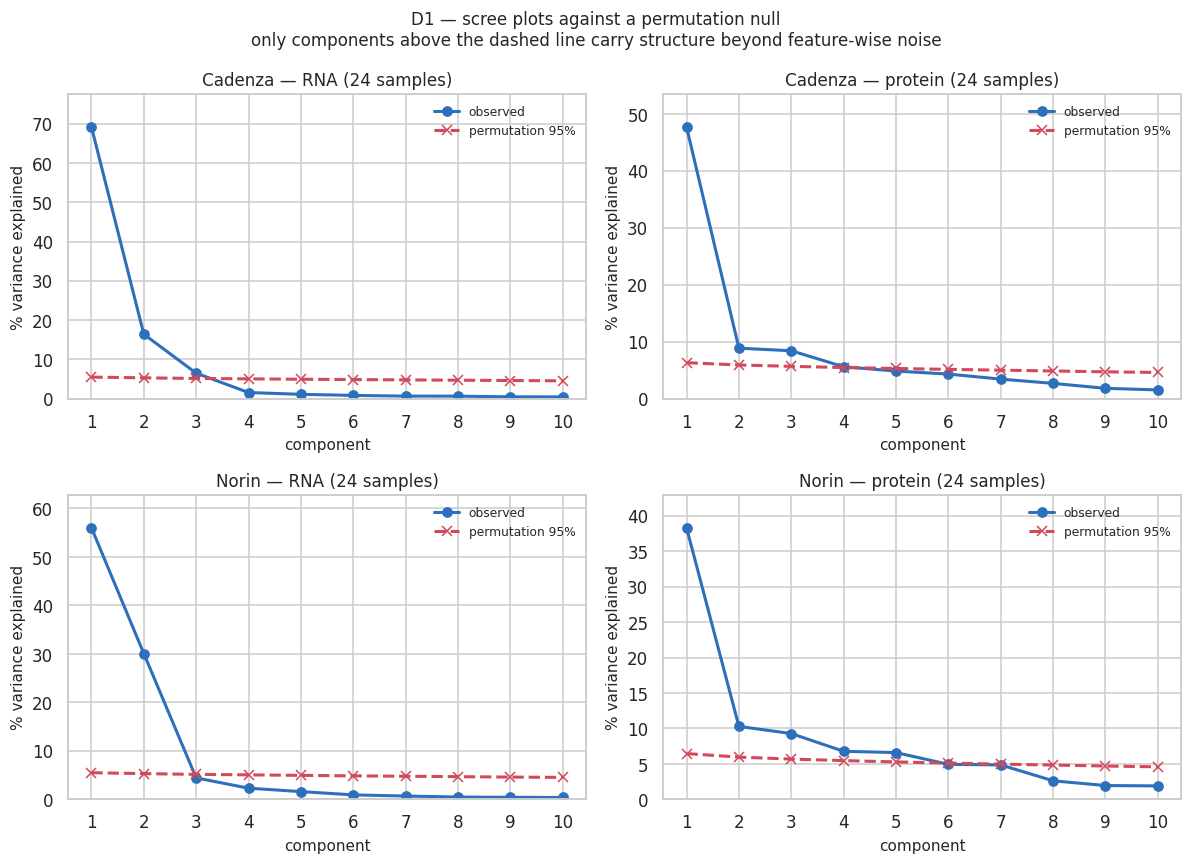

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, lab, fld) in zip(axes.ravel(), [
        (n, l, f) for n in BLOCKS for l, f in
        (("RNA (24 samples)", "R_samp"), ("protein (24 samples)", "P_samp"))]):
    d = d1[(d1.variety == name) & (d1.layer == lab) & (d1.component <= 10)]
    ax.plot(d.component, d.observed, "o-", lw=2, color=BLUE, label="observed")
    ax.plot(d.component, d.perm_q95, "x--", lw=2, color=RED, label="permutation 95%")
    ax.set(title=f"{name} — {lab}", xlabel="component", ylabel="% variance explained",
           ylim=(0, d.observed.max() * 1.12), xticks=range(1, 11))
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("D1 — scree plots against a permutation null\n"
             "only components above the dashed line carry structure beyond feature-wise noise",
             fontsize=11)
fig.tight_layout()
plt.show()

**How to read this.** Parallel analysis suggests most detectable variance structure is
concentrated in roughly **3–4 dimensions**.

That is evidence a small latent space is sensible. It is **not** proof that a 4th or 5th
low-variance direction carries no RNA→protein predictive information: parallel analysis tests
eigenvalues against a feature-independence null, it does not test predictive relevance. Treat
the `real = True` count as a reasonable default for *k*, not a hard ceiling.

---

# 5. D2 — Do the components track the design?

**The assumption being tested:** that PCA's leading directions correspond to the experimental
factors rather than to batch, handling, or an artefact.

The statistic is **η²** — the fraction of a component's variance explained by a factor — from
a one-way ANOVA of each PC score on treatment, and separately on timepoint. Computed with
`pingouin.anova(..., effsize="np2")`; for a one-way design, partial η² and η² coincide, so
this reproduces the R version's manual `SS_factor / SS_total` exactly.

In [16]:
def design_association(b, n_comp=4):
    '''Eta-squared of each leading RNA principal component on treatment and on timepoint.'''
    pca = PCA(n_components=n_comp).fit(b.R_samp)
    scores = pca.transform(b.R_samp)
    var_pct = 100 * PCA().fit(b.R_samp).explained_variance_ratio_[:n_comp]

    rows = []
    for j in range(n_comp):
        df = pd.DataFrame({
            "score":     scores[:, j],
            "treatment": b.meta["treatment"].astype(str).to_numpy(),
            "time":      b.meta["time_num"].astype(str).to_numpy(),
        })
        eta = {f: float(pg.anova(data=df, dv="score", between=f, effsize="np2")["np2"].iloc[0])
               for f in ("treatment", "time")}
        rows.append(dict(variety=b.label, component=j + 1, var_pct=round(var_pct[j], 1),
                         eta2_treatment=round(eta["treatment"], 3),
                         eta2_time=round(eta["time"], 3)))
    return pd.DataFrame(rows)


d2 = pd.concat([design_association(b) for b in BLOCKS.values()], ignore_index=True)
print("D2: fraction of each RNA principal component explained by treatment and by timepoint")
display(d2.set_index(["variety", "component"]))

D2: fraction of each RNA principal component explained by treatment and by timepoint


var_pct  eta2_treatment  eta2_time
variety component                                    
Cadenza 1             69.2           0.630      0.131
        2             16.4           0.110      0.842
        3              6.5           0.030      0.746
        4              1.5           0.002      0.216
Norin   1             56.0           0.186      0.714
        2             30.1           0.546      0.287
        3              4.4           0.010      0.689
        4              2.3           0.023      0.565

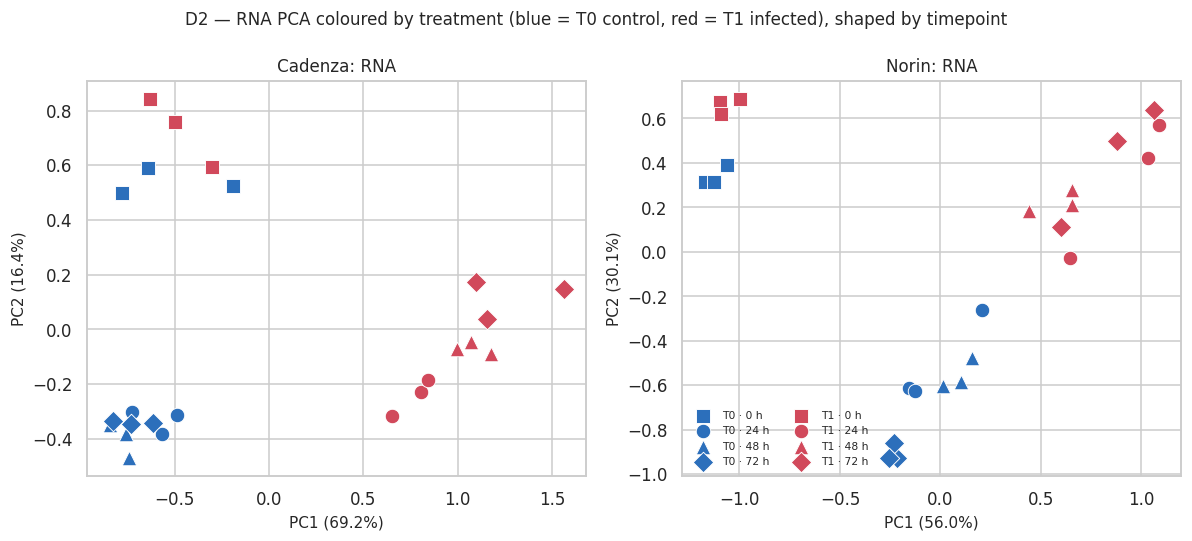

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
markers = {0: "s", 24: "o", 48: "^", 72: "D"}

for ax, (name, b) in zip(axes, BLOCKS.items()):
    pca = PCA(n_components=2).fit(b.R_samp)
    Z = pca.transform(b.R_samp)
    ve = 100 * pca.explained_variance_ratio_

    for tr, colour in zip(TREATMENTS, (BLUE, RED)):
        for t, mk in markers.items():
            sel = ((b.meta["treatment"] == tr) & (b.meta["time_num"] == t)).to_numpy()
            ax.scatter(Z[sel, 0], Z[sel, 1], c=colour, marker=mk, s=90,
                       edgecolor="white", linewidth=0.6,
                       label=f"{tr} · {t} h")
    ax.set(title=f"{name}: RNA", xlabel=f"PC1 ({ve[0]:.1f}%)", ylabel=f"PC2 ({ve[1]:.1f}%)")

axes[-1].legend(frameon=False, fontsize=7, ncol=2, loc="best")
fig.suptitle("D2 — RNA PCA coloured by treatment (blue = T0 control, red = T1 infected), "
             "shaped by timepoint", fontsize=11)
fig.tight_layout()
plt.show()

**Caveat.** This tests association with **treatment and timepoint only**. This design's
metadata carries no batch, sequencing-run or handling covariate, so a component that tracks
treatment/time is not thereby shown to be free of technical structure that happens to
correlate with it — there is simply nothing here to test that against.

The honest statement is: *the PCs strongly track the experimental design*. Not: *they track
it rather than batch*.

---

# 6. D3 — Is a linear autoencoder equivalent to PCA?

**The assumption being tested:** that the autoencoder implementation is correct, and that a
linear autoencoder adds nothing over PCA.

Baldi & Hornik (1989) proved the squared-error loss of a linear autoencoder has **no local
minima**, and that its global optimum spans the principal subspace. So a correct
implementation *must* recover the PCA subspace. This is simultaneously:

1. a **correctness check on the code** — if it fails, the optimiser or the architecture is wrong;
2. a **substantive result** — it establishes that any advantage a VAE has must come from
   non-linearity, not from being an autoencoder.

### Compare latent scores, not encoder weights

This distinction is not pedantry — getting it wrong makes a correct implementation look
broken.

With n = 24 samples and p = 2000 features, the data occupy a subspace of rank ≤ 23 out of
2000. `X @ W₁` therefore depends **only** on the component of `W₁` lying inside that row
space; any component orthogonal to it changes the weights while leaving every prediction
untouched. The encoder weight subspace is consequently **not identified** in the p ≫ n
regime.

The R notebook verified this directly: an autoencoder whose reconstruction MSE matched PCA's
optimum to 5 decimal places scored a weight-subspace cosine of **0.15**.

The latent **scores** (n × k) and the **reconstruction** *are* identified, so those are what
the theorem gets checked against. Principal angles come from
`scipy.linalg.subspace_angles`, replacing the R version's manual QR + SVD.

### One more gauge to quotient out: the encoder bias

`z = W₁x + b₁` and the decoder `x̂ = W₂z + b₂` are jointly invariant under
`(b₁, b₂) → (b₁ + c, b₂ − W₂c)` for any constant vector `c`. So **`b₁` is not identified
either** — the optimiser is free to leave it anywhere, and PyTorch initialises it at random.

A non-zero `b₁` adds a constant offset to every row of `Z`, which means `col(Z)` picks up a
component along the all-ones vector that has nothing to do with the data. Comparing raw
`Z` matrices then reports a spuriously large angle. Measured directly on this dataset: an
autoencoder whose reconstruction MSE matched PCA's optimum to 4 significant figures scored
a third cosine of **0.32** on raw scores and **1.000** once the scores were centred.

PCA's scores are centred by construction, so the fix is to centre the autoencoder's too —
one line, and it makes the comparison invariant to a gauge that carries no information.
(The R version happened to dodge this by initialising `b₁` at exactly zero, where it then
stayed; that is luck, not invariance.)

In [18]:
def subspace_alignment(X, k=3, epochs=5000, lr=0.02, seed=1):
    '''Compare a trained linear autoencoder against PCA on IDENTIFIED quantities.'''
    X = np.asarray(X, dtype=float)

    pca  = PCA(n_components=k).fit(X)
    Z_pc = pca.transform(X)
    rec_pca = pca.inverse_transform(Z_pc)

    model, hist = fit_autoencoder(X, k=k, kind="linear", epochs=epochs, lr=lr, seed=seed)
    Z_ae    = ae_encode(model, X)
    rec_ae  = ae_reconstruct(model, X)

    # Principal angles between the two k-dimensional score subspaces;
    # cos(angle) == 1 means the subspaces coincide.
    # Centre Z_ae first: the encoder bias b1 is an unidentified gauge (see above),
    # and an uncentred Z carries a spurious all-ones direction. Z_pc is already centred.
    cos = np.sort(np.cos(subspace_angles(Z_pc, Z_ae - Z_ae.mean(axis=0))))[::-1]

    return dict(
        cos_scores=cos,
        mean_cosine=float(cos.mean()),
        cor_reconstruction=float(np.corrcoef(rec_ae.ravel(), rec_pca.ravel())[0, 1]),
        mse_pca=float(((X - rec_pca) ** 2).mean()),
        mse_linear_ae=float(((X - rec_ae) ** 2).mean()),
        loss=hist,
    )


_d3 = {name: subspace_alignment(b.R_samp, k=3) for name, b in BLOCKS.items()}

d3 = pd.DataFrame([
    dict(variety=name,
         cos_score_1=round(r["cos_scores"][0], 4),
         cos_score_2=round(r["cos_scores"][1], 4),
         cos_score_3=round(r["cos_scores"][2], 4),
         mean_cosine=round(r["mean_cosine"], 4),
         cor_reconstruction=round(r["cor_reconstruction"], 4),
         mse_pca=float(f"{r['mse_pca']:.4g}"),
         mse_linear_ae=float(f"{r['mse_linear_ae']:.4g}"))
    for name, r in _d3.items()
]).set_index("variety")

print("D3: linear autoencoder vs PCA on identified quantities. Values near 1 confirm Baldi-Hornik.")
display(d3)

D3: linear autoencoder vs PCA on identified quantities. Values near 1 confirm Baldi-Hornik.


,cos_score_1,cos_score_2,cos_score_3,mean_cosine,cor_reconstruction,mse_pca,mse_linear_ae
variety,,,,,,,
Cadenza,1.0,1.0,1.0,1.0,1.0000,0.000040,0.000040
Norin,1.0,1.0,1.0,1.0,0.9992,0.000047,0.000048


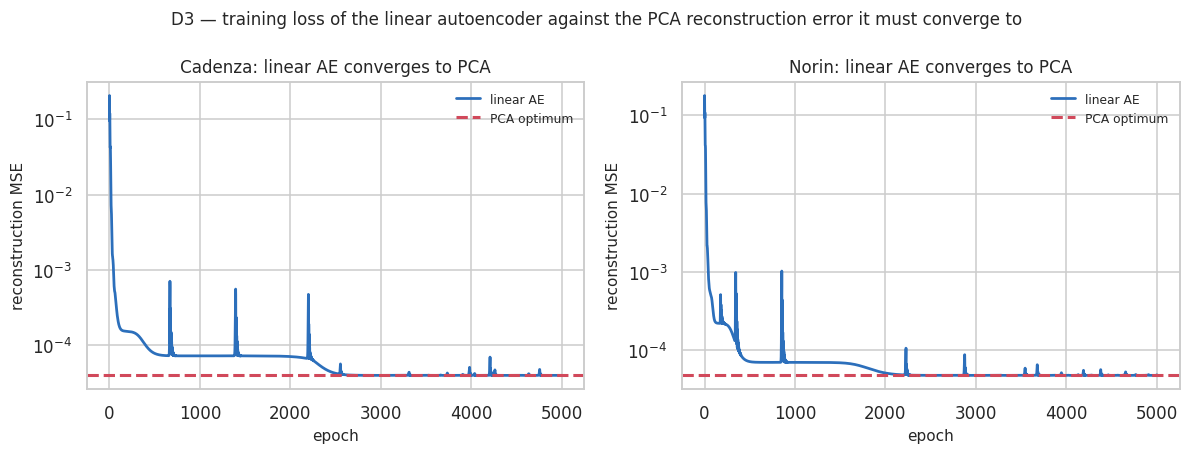

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, r) in zip(axes, _d3.items()):
    ax.plot(r["loss"], lw=1.8, color=BLUE, label="linear AE")
    ax.axhline(r["mse_pca"], ls="--", lw=2, color=RED, label="PCA optimum")
    ax.set(yscale="log", xlabel="epoch", ylabel="reconstruction MSE",
           title=f"{name}: linear AE converges to PCA")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("D3 — training loss of the linear autoencoder against the PCA "
             "reconstruction error it must converge to", fontsize=11)
fig.tight_layout()
plt.show()

**Caveat, and how this connects to D4.**

This confirms the optimiser recovers the PCA solution **on the full 24-sample block**. It does
not by itself prove the optimiser behaves as well inside a 7-condition D4 training fold, which
is a much smaller and differently-shaped problem. That fold-level rerun has not been done and
is listed as open work in §11.

Separately: confirming the *subspace* is shared is not the same as confirming the two methods
were **scored fairly** against each other in D4. A linear AE's latent scale is a free gauge
parameter while PCA's scores carry a meaningful variance-ordered scale, so a fixed ridge
`alpha` regularises them differently even when the subspace is identical. That is fixed where
the scoring actually happens — `pred_ae_ridge` (§3.3) re-scales the latent block on training
data before ridge.

---

# 7. D4 — Does any method beat predicting the mean?

**This is the headline comparison.**

Every method is scored by **leave-one-condition-out (LOCO)** cross-validation: hold out one of
the 8 treatment × timepoint cells entirely, fit on the remaining 7, predict the held-out
cell's protein profile. This matches `leave_condition_out` in `rnaprot/unpaired.py`.

Fold construction uses `sklearn.model_selection.LeaveOneGroupOut` with the design cell as the
group — so "a fold is a whole condition" is expressed by the splitter rather than by index
arithmetic that could quietly go wrong.

## The two reference points

**The mean baseline.** Predict the training-set average protein profile, ignoring RNA
completely. A method that cannot beat this is not extracting usable information. By
construction it scores exactly **Q² = 0**.

**The design baseline** (ridge on additive `treatment + time_f` indicators). A method that
only matches this is recovering the experimental design, not cross-layer biology.

Because D2 shows treatment and timepoint dominating RNA variance, an *additive* design
baseline is a **weak bar** — it cannot rule out that RNA is simply a good encoding of a
*non-additive* treatment × time response.

**`design-resid PLS` is the strong version of that test.** Residualise both blocks on an
*interactive* (`treatment * time_f`) design using training-fold coefficients only, fit PLS on
the residuals, then add the design-explained part back before scoring — so it is directly
comparable to every other row on the same target. If RNA offers nothing beyond design, this
row collapses to the design baseline's Q².

## On `k` and `alpha`

Every method uses a fixed `k = 2` / ridge `alpha = 10`, **chosen a priori, not tuned by an
inner cross-validation loop**. Full nested-CV tuning for every method was judged not worth
the complexity at n = 7 training conditions. This is a deliberate, flagged choice, not an
oversight — it is listed as open work in §11.

## Fold safety

`X_raw` / `Y_raw` are the **uncentred** condition means (`R_cond_raw` / `P_cond_raw`).
Centring and scaling are refit from the 7 training conditions inside every fold, via
`fold_matrices` (§3.4), and applied to the held-out condition using those training-only
parameters.

This matters *specifically* for the condition-aligned AE: its prediction is a homogeneous
linear map with no intercept (`dec_p(enc_r(x))`), so if the full 8-condition matrix were
centred before splitting, the held-out row would be an exact linear combination of the
training rows and `predict(xᵢ)` would track `−Σⱼ predict(xⱼ)` by linearity alone — regardless
of whether the fit is any good. PLS and PCA+ridge are largely (not entirely) insulated
because they re-centre on training means internally and carry an effective intercept. The
condition-aligned AE has neither, so this is not optional for it.

In [20]:
D4_METHODS = ["mean", "design", "PCA+ridge", "PLS", "design-resid PLS",
              "AE-linear", "AE-tanh", "AE-vae", "condition-aligned AE"]


def loco_compare(b, k=2, seeds=(1, 2, 3), Y_raw=None,
                 ae_epochs=4000, cond_epochs=3000, methods=None):
    '''Leave-one-condition-out Q2 for every method, on one variety.

    Fold-safe throughout: scaling and the design-residualisation coefficients are
    fitted on the 7 training conditions only, never on the full 8-condition matrix.

    `Y_raw`, `seeds` and the epoch counts are parameters (not hard-coded) so that
    the SAME function drives both the headline run and the permutation-null draws
    -- one implementation, not two copies that can drift apart.
    '''
    methods = D4_METHODS if methods is None else methods
    X_raw = b.R_cond_raw.to_numpy(dtype=float)
    Y_raw = b.P_cond_raw.to_numpy(dtype=float) if Y_raw is None else np.asarray(Y_raw, float)

    cells = b.cond["cell"].to_numpy()
    D_add, D_int = design_matrices(b.cond)

    press = {m: 0.0 for m in methods}
    tss = 0.0

    for tr, te in LeaveOneGroupOut().split(X_raw, groups=cells):
        Xtr, Xte, Ytr, Yte = fold_matrices(X_raw, Y_raw, tr, te)
        sq = lambda pred: float(((Yte - np.asarray(pred).reshape(Yte.shape)) ** 2).sum())

        # TSS uses the training-mean predictor -- the same reference the mean baseline uses
        tss += float(((Yte - Ytr.mean(axis=0)) ** 2).sum())

        if "mean" in press:
            press["mean"] += sq(pred_mean(Xtr, Ytr, Xte))
        if "design" in press:
            press["design"] += sq(pred_design(Xtr, Ytr, Xte, D_add[tr], D_add[te]))
        if "PCA+ridge" in press:
            press["PCA+ridge"] += sq(pred_pca_ridge(Xtr, Ytr, Xte, k=k))
        if "PLS" in press:
            press["PLS"] += sq(pred_pls(Xtr, Ytr, Xte, k=k))

        if "design-resid PLS" in press:
            # residualise BOTH blocks on the interactive design, training rows only,
            # then add the design-explained part back so the target is unchanged
            rx = Ridge(alpha=5).fit(D_int[tr], Xtr)
            ry = Ridge(alpha=5).fit(D_int[tr], Ytr)
            Xtr_r = Xtr - rx.predict(D_int[tr])
            Xte_r = Xte - rx.predict(D_int[te])
            Ytr_r = Ytr - ry.predict(D_int[tr])
            press["design-resid PLS"] += sq(
                ry.predict(D_int[te]) + pred_pls(Xtr_r, Ytr_r, Xte_r, k=k))

        # autoencoders: averaged over seeds, because they are non-convex
        for kind in ("linear", "tanh", "vae"):
            name = f"AE-{kind}"
            if name in press:
                preds = [pred_ae_ridge(Xtr, Ytr, Xte, k=k, kind=kind,
                                       epochs=ae_epochs, seed=s) for s in seeds]
                press[name] += sq(np.mean(preds, axis=0))

        if "condition-aligned AE" in press:
            preds = [pred_cond_ae(Xtr, Ytr, Xte, cond_tr=cells[tr], k=k,
                                  epochs=cond_epochs, seed=s) for s in seeds]
            press["condition-aligned AE"] += sq(np.mean(preds, axis=0))

    return pd.DataFrame({"variety": b.label, "method": list(press),
                         "Q2": [round(q2_from_press(p, tss), 4) for p in press.values()]})

In [21]:
_t0 = time.time()
d4 = pd.concat([loco_compare(b) for b in BLOCKS.values()], ignore_index=True)
d4 = d4.sort_values(["variety", "Q2"], ascending=[True, False]).reset_index(drop=True)
print(f"D4 fitted in {time.time() - _t0:.0f} s")

print("\nD4: leave-one-condition-out Q2 for predicting the protein block.")
print("Q2 <= 0 means no better than predicting the mean.")
display(d4.set_index(["variety", "method"]))

D4 fitted in 420 s

D4: leave-one-condition-out Q2 for predicting the protein block.
Q2 <= 0 means no better than predicting the mean.


Q2
variety method                      
Cadenza condition-aligned AE  0.3686
        PLS                   0.3373
        design-resid PLS      0.3159
        AE-vae                0.2623
        AE-tanh               0.2522
        AE-linear             0.2420
        PCA+ridge             0.2237
        design                0.0247
        mean                  0.0000
Norin   condition-aligned AE  0.1822
        AE-vae                0.1261
        AE-linear             0.1227
        AE-tanh               0.1191
        PCA+ridge             0.1085
        design-resid PLS      0.0536
        PLS                   0.0275
        design                0.0082
        mean                  0.0000

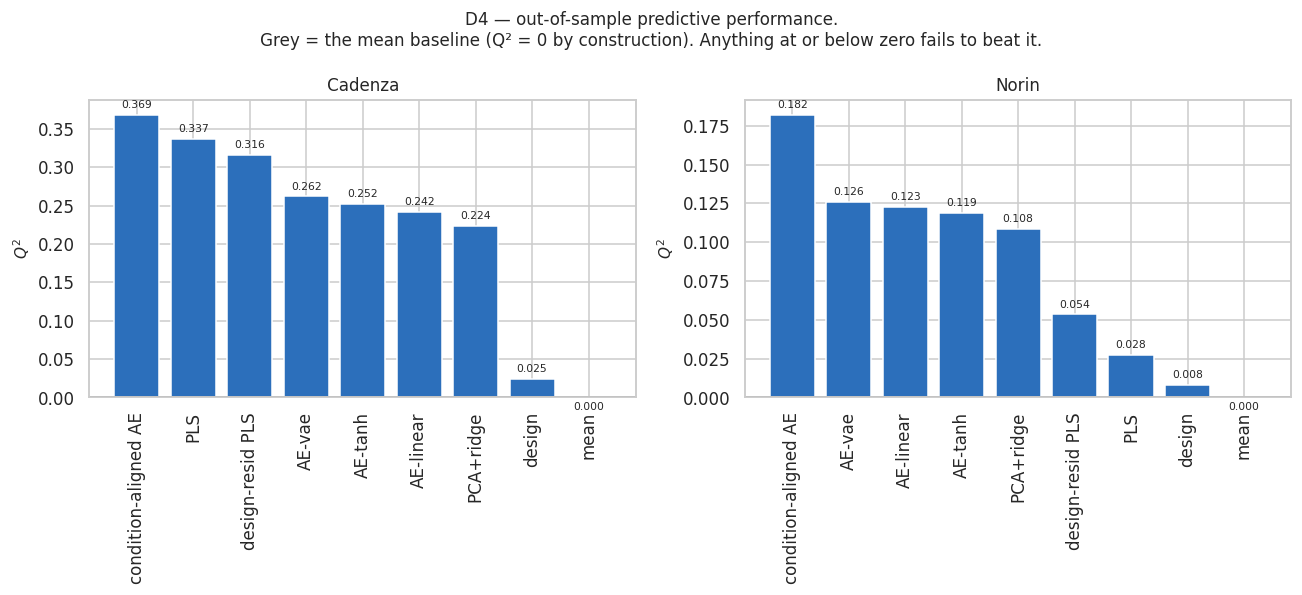

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=False)
for ax, name in zip(axes, d4.variety.unique()):
    d = d4[d4.variety == name]
    colours = [GREY if m == "mean" else (BLUE if q > 0 else RED)
               for m, q in zip(d.method, d.Q2)]
    bars = ax.bar(d.method, d.Q2, color=colours)
    ax.axhline(0, color="black", lw=1.2)
    ax.set(title=name, ylabel="$Q^2$")
    ax.tick_params(axis="x", rotation=90)
    for bar, q in zip(bars, d.Q2):
        ax.annotate(f"{q:.3f}", (bar.get_x() + bar.get_width() / 2, q),
                    ha="center", va="bottom" if q > 0 else "top", fontsize=7,
                    xytext=(0, 3 if q > 0 else -3), textcoords="offset points")

fig.suptitle("D4 — out-of-sample predictive performance.\n"
             "Grey = the mean baseline (Q² = 0 by construction). "
             "Anything at or below zero fails to beat it.", fontsize=11)
fig.tight_layout()
plt.show()

---

## 7a. D4 permutation null — is any of this reachable by chance?

A point-estimate Q² is not enough at n = 8. D7 (§7b) shows that an unpermuted-looking PLS Q²
is reachable by chance at this sample size, so **every** method in D4 needs its own null, not
just PLS.

The null reshuffles **which condition's protein data belongs to which condition's RNA data**
(`permute_y_by_cell`, §3.4) and refits everything from scratch — the accepted procedure for
small-n omics PLS (Westerhuis *et al.* 2008).

**This version runs the null at full fidelity.** The R notebook had to cut the autoencoder
null draws to 1 seed and reduced epochs (1000 / 600 instead of 4000 / 3000) for tractability,
which left the AE rows' p-values noisier than the closed-form methods'. That was flagged as
open work. Here the null draws use **exactly the same settings as the observed run** — same
seeds, same epochs — and the draws are distributed across cores with `joblib`. The extra
compute available on this machine is what closes that gap.

`n_perm = 199` gives a minimum attainable p-value of 1/200 = 0.005.

In [23]:
N_PERM_D4 = 199


def _d4_null_draw(b, s, k=2):
    '''One permutation draw: reshuffle condition correspondence, then rerun all of D4.'''
    rng = np.random.default_rng(40_000 + s)
    Yp = permute_y_by_cell(b.P_cond_raw.to_numpy(dtype=float),
                           b.P_cond_raw.index.to_numpy(), rng)
    return loco_compare(b, k=k, Y_raw=Yp)          # same seeds/epochs as the observed run


_t0 = time.time()
d4_null = {
    name: pd.concat(
        Parallel(n_jobs=N_JOBS, verbose=0)(
            delayed(_d4_null_draw)(b, s) for s in range(N_PERM_D4)),
        ignore_index=True)
    for name, b in BLOCKS.items()
}
print(f"D4 permutation null: {N_PERM_D4} draws x {len(BLOCKS)} varieties "
      f"in {time.time() - _t0:.0f} s")

D4 permutation null: 199 draws x 2 varieties in 2921 s


In [24]:
rows = []
for name, nd in d4_null.items():
    obs = d4[d4.variety == name].set_index("method")["Q2"]
    for m, q in obs.items():
        null_m = nd.loc[nd.method == m, "Q2"].to_numpy()
        rows.append(dict(
            variety=name, method=m, Q2=q,
            null_median=round(float(np.median(null_m)), 4),
            null_p95=round(float(np.quantile(null_m, 0.95)), 4),
            # one-sided empirical p-value, with the +1 correction (Phipson & Smyth 2010)
            p_perm=round((np.sum(null_m >= q) + 1) / (len(null_m) + 1), 4),
        ))

d4_perm = (pd.DataFrame(rows)
           .sort_values(["variety", "Q2"], ascending=[True, False])
           .reset_index(drop=True))

print(f"D4 permutation null ({N_PERM_D4} draws). "
      "p_perm is one-sided: P(null Q2 >= observed Q2).")
display(d4_perm.set_index(["variety", "method"]))

D4 permutation null (199 draws). p_perm is one-sided: P(null Q2 >= observed Q2).


Q2  null_median  null_p95  p_perm
variety method                                                     
Cadenza condition-aligned AE  0.3686      -0.5515    0.1892   0.010
        PLS                   0.3373      -0.3594    0.1615   0.005
        design-resid PLS      0.3159      -0.4500    0.1203   0.010
        AE-vae                0.2623      -0.0413    0.1088   0.015
        AE-tanh               0.2522      -0.0439    0.1074   0.010
        AE-linear             0.2420      -0.0439    0.1016   0.005
        PCA+ridge             0.2237      -0.0359    0.0926   0.010
        design                0.0247      -0.0186    0.1006   0.280
        mean                  0.0000       0.0000    0.0000   1.000
Norin   condition-aligned AE  0.1822      -0.4577   -0.0244   0.005
        AE-vae                0.1261      -0.0293    0.0633   0.010
        AE-linear             0.1227      -0.0357    0.0722   0.015
        AE-tanh               0.1191      -0.0319    0.0714   0.010
        PCA+ridge             0.1085      -0.0277    0.0684   0.010
        design-resid PLS      0.0536      -0.4457   -0.0768   0.005
        PLS                   0.0275      -0.4149   -0.0503   0.010
        design                0.0082      -0.0178    0.0703   0.325
        mean                  0.0000       0.0000    0.0000   1.000

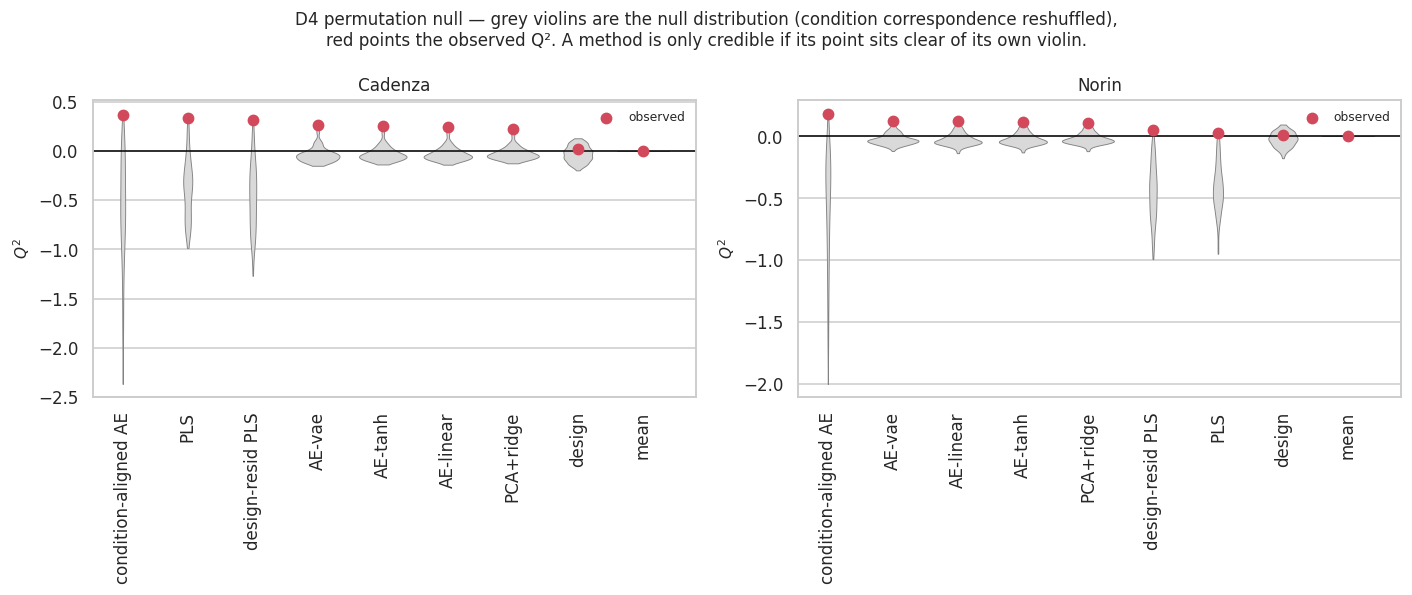

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, name in zip(axes, BLOCKS):
    nd  = d4_null[name]
    obs = d4[d4.variety == name].set_index("method")["Q2"]
    order = list(obs.index)

    sns.violinplot(data=nd[nd.method.isin(order)], x="method", y="Q2", order=order,
                   ax=ax, color="#D9D9D9", inner=None, cut=0, linewidth=0.6)
    ax.scatter(range(len(order)), obs[order].to_numpy(), color=RED, zorder=5, s=45,
               label="observed")
    ax.axhline(0, color="black", lw=1)
    ax.set(title=name, ylabel="$Q^2$", xlabel="")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("D4 permutation null — grey violins are the null distribution "
             "(condition correspondence reshuffled),\nred points the observed Q². "
             "A method is only credible if its point sits clear of its own violin.",
             fontsize=11)
fig.tight_layout()
plt.show()

---

# 7b. D7 — Condition means or individual replicates for the cross-block fit?

D4 fits every method on **condition means** (8 rows). That was a choice, not the only option,
and it deserves a test rather than an assertion.

## Why "individual samples" is not simply the other option

Under the unpaired design there is **no real sample-level correspondence** between an RNA
plant and a protein plant. A cross-block fit on 24 "paired" rows therefore requires
*inventing* a pairing, and there are two ways to do that — which are not equivalent:

**Fixed label pairing.** Match RNA replicate *i* to protein replicate *i* by row order (same
field-plot label) and trust it. This is what the private reference notebook's sample-level
sPLS sections assumed (`stopifnot(all(rownames(cadenza.X_prot) == rownames(cadenza.X_rnaseq)))`).
The label is *fictional biology*: any within-cell covariance this pairing contributes is not
real signal, it is **one arbitrary draw from noise**, and it can inflate or deflate Q² by
chance.

**Replicate-pairing bootstrap.** Within each cell, randomly permute which RNA replicate is
matched to which protein replicate, refit, repeat over many draws, average. Because the
pairing is randomised, the within-cell covariance it induces is **zero in expectation** — what
survives averaging is the between-cell signal, which is the only signal this design licenses.

All three schemes are scored identically: **leave-one-condition-out** (never
leave-one-sample-out, which would let a fictional within-cell pairing leak across train/test),
against a permutation null that reshuffles condition correspondence.

**One statistical detail that was a genuine bug in an earlier R version.** The bootstrap's
observed statistic is a *mean over 30 pairings*. Its null must therefore also be built from
means over 30 pairings under a permuted correspondence — comparing a mean-of-30 against
*individual* null draws understates the null's spread. Fixed here, as in the current R
version.

> ### A second indexing bug, found while writing this port
>
> The R implementation of one bootstrap draw is:
>
> ```r
> draw_boot <- function(Y_source) {
>   ip <- unlist(lapply(idx, sample))          # idx = split(common, cell_s)
>   loco_on(Xf, Y_source[ip, , drop = FALSE], cell_s, k)
> }
> ```
>
> `split()` returns its groups in **factor-level order** (`T0_t0, T0_t24, T0_t48, T0_t72,
> T1_t0, ...`), but `Xf`'s rows are in **metadata order** (`T0_t0, T1_t0, T0_t24, T1_t24,
> ...`). `sample()` only permutes *within* each group, so the group ordering is never
> restored -- which means `Y_source[ip, ]` hands row *i* of `Xf` the protein data of a
> **different design cell**. Checked directly against this dataset: **18 of 24 rows** are
> mis-assigned.
>
> So R's "replicate-pairing bootstrap" was not re-pairing replicates within a condition. It
> was applying a *fixed between-condition scramble* -- essentially one draw from the
> permutation null -- which is exactly why it scored around -0.21 / -0.34 with a standard
> deviation of only ~0.002 across draws.
>
> `random_within_cell_pairing` below permutes **positions within each cell**, leaving cell
> membership untouched, which is what the scheme was designed to do. The consequence is that
> this notebook's bootstrap row **will not match R's, and should not** -- see §12. D7's
> reading below is written from the corrected numbers.

In [26]:
def loco_pls_q2(X_raw, Y_raw, cell_of, k=2):
    '''Leave-one-condition-out PLS Q2, generic over row count.

    Works for the 8-row condition-mean scheme and the 24-row sample-level schemes
    alike: rows sharing a `cell_of` label are matched X<->Y row-by-row within that
    label. Fold-safe -- X_raw/Y_raw are RAW and scaling is fitted per fold.
    '''
    X_raw = np.asarray(X_raw, dtype=float)
    Y_raw = np.asarray(Y_raw, dtype=float)
    press = tss = 0.0
    for tr, te in LeaveOneGroupOut().split(X_raw, groups=np.asarray(cell_of)):
        Xtr, Xte, Ytr, Yte = fold_matrices(X_raw, Y_raw, tr, te)
        press += float(((Yte - pred_pls(Xtr, Ytr, Xte, k=k).reshape(Yte.shape)) ** 2).sum())
        tss   += float(((Yte - Ytr.mean(axis=0)) ** 2).sum())
    return q2_from_press(press, tss)


def random_within_cell_pairing(idx_by_cell, n_rows, rng):
    '''A row permutation that only ever swaps rows WITHIN a design cell.'''
    perm = np.arange(n_rows)
    for idx in idx_by_cell:
        perm[idx] = rng.permutation(idx)
    return perm

In [27]:
N_PAIRINGS  = 30     # random within-cell pairings averaged for the bootstrap statistic
N_PERM_D7   = 199    # permutation draws for the condition-mean and fixed-pairing schemes
N_PERM_BOOT = 199    # permutation draws for the bootstrap scheme (each = mean of N_PAIRINGS)


def pairing_compare(b, k=2, seed=1):
    '''Compare three ways of building the cross-block training matrix.'''
    Xc, Yc = b.R_cond_raw.to_numpy(float), b.P_cond_raw.to_numpy(float)
    cell_c = b.R_cond_raw.index.to_numpy()

    common = [s for s in b.R_samp_raw.index if s in set(b.P_samp_raw.index)]
    Xf = b.R_samp_raw.loc[common].to_numpy(float)
    Yf = b.P_samp_raw.loc[common].to_numpy(float)
    cell_s = b.meta.loc[common, "cell"].astype(str).to_numpy()
    idx_by_cell = [np.flatnonzero(cell_s == cl) for cl in CELLS]

    # ---- (a) condition means, n = 8 ------------------------------------------
    q2_cond = loco_pls_q2(Xc, Yc, cell_c, k)
    null_cond = Parallel(n_jobs=N_JOBS)(
        delayed(loco_pls_q2)(
            Xc, permute_y_by_cell(Yc, cell_c, np.random.default_rng(70_000 + s)), cell_c, k)
        for s in range(N_PERM_D7))

    # ---- (b) fixed label pairing, n = 24 -------------------------------------
    q2_fixed = loco_pls_q2(Xf, Yf, cell_s, k)
    null_fixed = Parallel(n_jobs=N_JOBS)(
        delayed(loco_pls_q2)(
            Xf, permute_y_by_cell(Yf, cell_s, np.random.default_rng(71_000 + s)), cell_s, k)
        for s in range(N_PERM_D7))

    # ---- (c) replicate-pairing bootstrap, n = 24 -----------------------------
    def boot_mean(Y_source, base_seed):
        '''Mean Q2 over N_PAIRINGS random within-cell re-pairings of Y_source.'''
        out = []
        for j in range(N_PAIRINGS):
            rng = np.random.default_rng(base_seed * 1000 + j)
            perm = random_within_cell_pairing(idx_by_cell, len(cell_s), rng)
            out.append(loco_pls_q2(Xf, Y_source[perm], cell_s, k))
        return np.array(out)

    q2_boot_draws = boot_mean(Yf, seed)

    # the null must use the SAME statistic: a mean over N_PAIRINGS, not a single draw
    null_boot = Parallel(n_jobs=N_JOBS)(
        delayed(lambda s: boot_mean(
            permute_y_by_cell(Yf, cell_s, np.random.default_rng(72_000 + s)),
            80_000 + s).mean())(s)
        for s in range(N_PERM_BOOT))

    # how favourable was the ONE fixed pairing, among random within-cell pairings?
    fixed_pctile = float(np.mean(q2_boot_draws <= q2_fixed))

    pval = lambda obs, null: round((np.sum(np.asarray(null) >= obs) + 1) / (len(null) + 1), 4)

    return pd.DataFrame({
        "variety": b.label,
        "scheme": ["condition means", "fixed label pairing", "replicate-pairing bootstrap"],
        "n_rows": [Xc.shape[0], Xf.shape[0], Xf.shape[0]],
        "Q2": np.round([q2_cond, q2_fixed, q2_boot_draws.mean()], 4),
        "Q2_sd_over_pairings": [np.nan, np.nan, round(float(q2_boot_draws.std(ddof=1)), 4)],
        "null_p95": np.round([np.quantile(null_cond, .95), np.quantile(null_fixed, .95),
                              np.quantile(null_boot, .95)], 4),
        "p_perm": [pval(q2_cond, null_cond), pval(q2_fixed, null_fixed),
                   pval(q2_boot_draws.mean(), null_boot)],
        "fixed_pairing_pctile": [np.nan, round(fixed_pctile, 3), np.nan],
    })


_t0 = time.time()
d7 = pd.concat([pairing_compare(b) for b in BLOCKS.values()], ignore_index=True)
print(f"D7 in {time.time() - _t0:.0f} s\n")
print("D7: PLS-only leave-one-condition-out Q2 under three ways of building the")
print("cross-block training matrix. `fixed_pairing_pctile` is the fraction of random")
print("within-cell pairings scoring at or below the ONE fixed pairing -- close to 1")
print("means that pairing was an unusually favourable draw.")
display(d7.set_index(["variety", "scheme"]))

D7 in 93 s

D7: PLS-only leave-one-condition-out Q2 under three ways of building the
cross-block training matrix. `fixed_pairing_pctile` is the fraction of random
within-cell pairings scoring at or below the ONE fixed pairing -- close to 1
means that pairing was an unusually favourable draw.


n_rows      Q2  Q2_sd_over_pairings  \
variety scheme                                                             
Cadenza condition means                   8  0.3373                  NaN   
        fixed label pairing              24  0.2793                  NaN   
        replicate-pairing bootstrap      24  0.2775               0.0023   
Norin   condition means                   8  0.0275                  NaN   
        fixed label pairing              24  0.0296                  NaN   
        replicate-pairing bootstrap      24  0.0286               0.0072   

                                     null_p95  p_perm  fixed_pairing_pctile  
variety scheme                                                               
Cadenza condition means                0.1867   0.010                   NaN  
        fixed label pairing            0.0691   0.010                 0.833  
        replicate-pairing bootstrap    0.0672   0.005                   NaN  
Norin   condition means               -0.0118   0.025                   NaN  
        fixed label pairing           -0.0469   0.025                 0.333  
        replicate-pairing bootstrap   -0.0502   0.020                   NaN

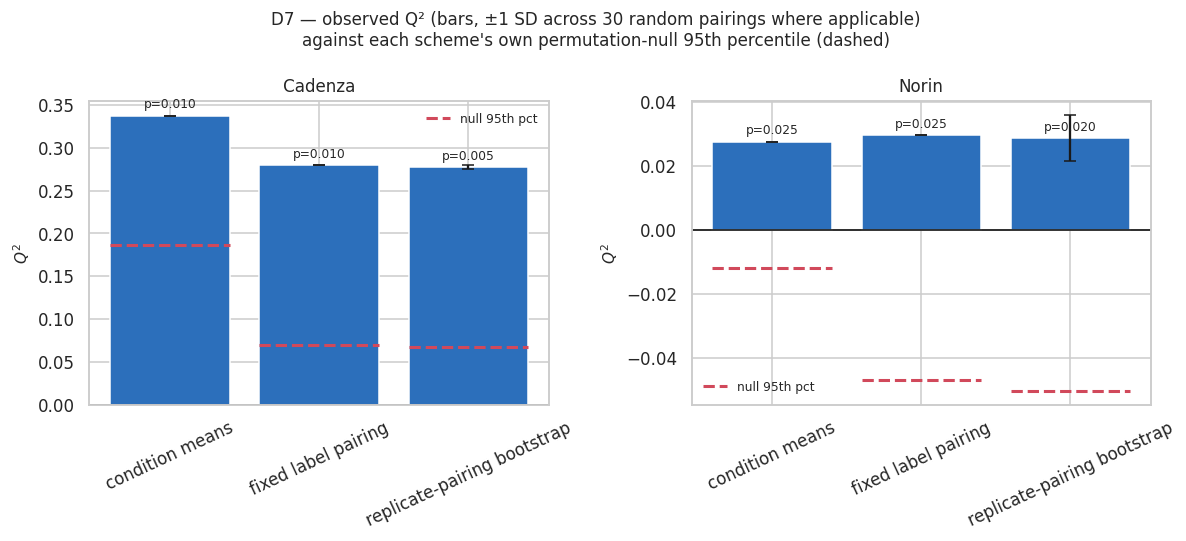

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, d7.variety.unique()):
    d = d7[d7.variety == name]
    err = d.Q2_sd_over_pairings.fillna(0).to_numpy()
    bars = ax.bar(d.scheme, d.Q2, color=BLUE, yerr=err, capsize=4)
    for i, (x, p95) in enumerate(zip(bars, d.null_p95)):
        ax.hlines(p95, i - 0.4, i + 0.4, color=RED, ls="--", lw=2,
                  label="null 95th pct" if i == 0 else None)
    for i, (q, p) in enumerate(zip(d.Q2, d.p_perm)):
        ax.annotate(f"p={p:.3f}", (i, max(q, d.null_p95.iloc[i])), ha="center",
                    xytext=(0, 5), textcoords="offset points", fontsize=8)
    ax.axhline(0, color="black", lw=1)
    ax.set(title=name, ylabel="$Q^2$")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("D7 — observed Q² (bars, ±1 SD across 30 random pairings where applicable)\n"
             "against each scheme's own permutation-null 95th percentile (dashed)", fontsize=11)
fig.tight_layout()
plt.show()

**Reading D7.**

Read the three `Q2` values together with the `Q2_sd_over_pairings` and `p_perm` columns above.
Three things follow from them.

**1. Aggregating to condition means costs nothing, and in Cadenza it helps.** The expectation
going in was the opposite — 21 training rows per fold ought to beat 7, since more data usually
helps — so the result is worth explaining rather than just noting. A single replicate is a much
noisier observation than a condition mean, and condition-mean aggregation averages that
replicate noise out *before* the cross-block fit ever sees the data. The sample-level schemes
hand the model 3× the rows at a worse per-row signal-to-noise ratio, and PLS with two
components cannot separate the added noise from the between-condition signal it is trying to
learn. **More rows did not mean more information here.** In Norin the three schemes are
effectively tied — well within the bootstrap's own spread across pairings — so there the honest
reading is that the choice does not matter, not that aggregation wins.

**2. The bootstrap is not catastrophic — and the R notebook's claim that it was is an artefact
of the indexing bug described above.** Once the re-pairing is genuinely *within* cell, the
bootstrap lands close to the fixed pairing, which is what theory predicts: randomising which
replicate pairs with which destroys within-cell covariance *in expectation* but leaves the
between-cell signal — the only signal this design licenses — intact. Its very small SD across
30 pairings says the same thing from the other direction: the choice of pairing barely matters,
because almost none of the predictive signal lives at the within-cell level.

**3. The fixed label pairing is still not a safe default**, whatever it scores. Its result
depends on one arbitrary, unrepeatable draw of which replicate got matched to which. The
`fixed_pairing_pctile` column quantifies how favourable that draw was, relative to the full
distribution of random within-cell pairings. A favourable draw here says nothing about a new
dataset — and the underlying label was never biological correspondence to begin with.

**Conclusion: use condition means.** Not because individual samples were never tried, but
because they were tried two ways, neither beat aggregation, and one of them rests on a
correspondence that does not exist.

---

# 7c. D8 — Does global feature selection leak?

`make_blocks` (§1.7) selects the top-variable RNA genes **once, using all 24 samples**, before
any cross-validation loop runs. `rnaprot/unpaired_reviewer.py` instead re-selects features
**inside each outer fold**, using only that fold's training samples.

If global selection leaks, D4/D7's Q² is optimistic relative to what a genuinely unseen
condition would get. This measures the gap directly.

**Scope of the check.** This tests the RNA (X) side only, holding the protein (Y) target set
fixed at the same 1000 proteins D4/D7 use. Re-selecting Y in-fold as well would change *which
proteins are being predicted* from fold to fold, which breaks a single pooled Q² across folds.
So this answers whether X-side selection leakage matters, not Y-side.

In [29]:
def loco_infold_feature_selection(v, hv_p_fixed, n_rna=2000, k=2):
    '''LOCO PLS Q2 with RNA feature selection redone inside each fold.

    Protein features are held fixed so the prediction target is the same in every
    fold. Fold-safe: both the feature selection and the scaling see training rows only.
    '''
    meta = v.meta
    P_cond_raw = cell_means(v.prot.loc[hv_p_fixed], meta).T.to_numpy(dtype=float)
    cells = np.array(CELLS)

    press = tss = 0.0
    for cl in CELLS:
        train_samples = meta.index[(meta["cell"] != cl).to_numpy()]

        # feature selection uses TRAINING SAMPLES ONLY -- this is the whole point
        hv_r = top_variable(v.vst[train_samples], n_rna)
        R_cond_raw = cell_means(v.vst.loc[hv_r], meta).T.to_numpy(dtype=float)

        te = np.flatnonzero(cells == cl)
        tr = np.flatnonzero(cells != cl)
        Xtr, Xte, Ytr, Yte = fold_matrices(R_cond_raw, P_cond_raw, tr, te)

        press += float(((Yte - pred_pls(Xtr, Ytr, Xte, k=k).reshape(Yte.shape)) ** 2).sum())
        tss   += float(((Yte - Ytr.mean(axis=0)) ** 2).sum())

    return q2_from_press(press, tss)


d8 = pd.DataFrame([
    dict(variety=name,
         Q2_global_selection=float(d4.loc[(d4.variety == name) & (d4.method == "PLS"), "Q2"].iloc[0]),
         Q2_infold_selection=round(loco_infold_feature_selection(
             v, top_variable(v.prot, 1000)), 4))
    for name, v in VARIETIES.items()
])
d8["gap"] = (d8.Q2_global_selection - d8.Q2_infold_selection).round(4)

print("D8: PLS leave-one-condition-out Q2, global (§7) vs in-fold RNA feature selection.")
print("gap > 0 would mean global selection was optimistic (i.e. it leaked).")
display(d8.set_index("variety"))

D8: PLS leave-one-condition-out Q2, global (§7) vs in-fold RNA feature selection.
gap > 0 would mean global selection was optimistic (i.e. it leaked).


,Q2_global_selection,Q2_infold_selection,gap
variety,,,
Cadenza,0.3373,0.3721,-0.0348
Norin,0.0275,0.0584,-0.0309


---

# 7d. D9 — Sample-level condition-aligned AE: the real test of centroid alignment

D4's condition-aligned AE was fit on **7 condition-mean rows per fold**. At that scale the
architecture's defining idea degenerates: *"align z_r's condition centroid with z_p's condition
centroid"* is vacuous when a centroid is computed over a **single row** — it *is* that row. The
alignment loss term `w₄` is never exercised as designed.

So the mechanism this architecture exists to test — **whether averaging 3 noisy replicate
embeddings into a centroid still lines up across modalities** — was never actually run in D4.

This runs it as designed: fit on the **21 RNA + 21 protein replicate-level rows per fold**
(3 replicates × 7 training conditions, in each layer independently), holding out all 3
replicates of one condition in **both** layers at once — never a partial condition, which
would leak.

There is still no per-replicate protein ground truth under the unpaired design, so evaluation
is against the same held-out **condition mean** D4/D7/D8 use. Only the training side changes.

`fit_condition_ae` supports this without modification: `R` and `P` may have different row
counts, tied only through the `cond_r` / `cond_p` grouping vectors.

In [30]:
def loco_cond_ae_sample_level(b, k=3, seeds=(1, 2, 3), epochs=3000):
    '''Condition-aligned AE trained on replicate-level rows, scored on condition means.

    Fold-safe: scalers are fitted from the 21 training REPLICATE rows in each layer
    independently (not from the 7 condition means), since that is the level the
    model is actually trained at here.
    '''
    R_raw = b.R_samp_raw.to_numpy(dtype=float)
    P_raw = b.P_samp_raw.to_numpy(dtype=float)
    Y_cond = b.P_cond_raw

    cell_r = b.meta.loc[b.R_samp_raw.index, "cell"].astype(str).to_numpy()
    cell_p = b.meta.loc[b.P_samp_raw.index, "cell"].astype(str).to_numpy()

    press = tss = 0.0
    for cl in CELLS:
        tr_r, tr_p = cell_r != cl, cell_p != cl

        sr = BlockScaler().fit(R_raw[tr_r])
        sp = BlockScaler().fit(P_raw[tr_p])
        Rtr, Rte = sr.transform(R_raw[tr_r]), sr.transform(R_raw[~tr_r])
        Ptr = sp.transform(P_raw[tr_p])

        # average the held-out condition's replicate predictions into one profile
        preds = []
        for s in seeds:
            model, _ = fit_condition_ae(Rtr, Ptr, cell_r[tr_r], cell_p[tr_p],
                                        k=k, epochs=epochs, seed=s)
            preds.append(cond_ae_predict(model, Rte).mean(axis=0))
        pred = np.mean(preds, axis=0)

        Yte = sp.transform(Y_cond.loc[[cl]].to_numpy(dtype=float)).ravel()
        Ytr_cond = sp.transform(Y_cond.drop(index=cl).to_numpy(dtype=float))

        press += float(((Yte - pred) ** 2).sum())
        tss   += float(((Yte - Ytr_cond.mean(axis=0)) ** 2).sum())

    return q2_from_press(press, tss)


_t0 = time.time()
d9 = pd.DataFrame([
    dict(variety=name,
         Q2_condition_level_D4=float(
             d4.loc[(d4.variety == name) & (d4.method == "condition-aligned AE"), "Q2"].iloc[0]),
         Q2_sample_level_D9=round(loco_cond_ae_sample_level(b), 4))
    for name, b in BLOCKS.items()
])
d9["change"] = (d9.Q2_sample_level_D9 - d9.Q2_condition_level_D4).round(4)
print(f"D9 in {time.time() - _t0:.0f} s\n")
print("D9: condition-aligned AE fit at the level it was designed for (21+21 replicate")
print("rows per fold, real n=3 centroids) vs D4's condition-mean fit (7 rows, alignment")
print("degenerate). Both evaluated against the same held-out condition mean.")
display(d9.set_index("variety"))

D9 in 151 s

D9: condition-aligned AE fit at the level it was designed for (21+21 replicate
rows per fold, real n=3 centroids) vs D4's condition-mean fit (7 rows, alignment
degenerate). Both evaluated against the same held-out condition mean.


,Q2_condition_level_D4,Q2_sample_level_D9,change
variety,,,
Cadenza,0.3686,0.2847,-0.0839
Norin,0.1822,0.1095,-0.0727


---

# 8. D5 — Are we sample-limited?

**The assumption being tested:** that 8 conditions suffice to fit these models.

If performance is still improving as training conditions are added, the models are
data-starved, and D4's comparison reflects sample size as much as method quality.

**Exhaustive, not sampled.** With only 8 conditions, every (test condition, training subset of
size *m*) combination is cheap to enumerate outright, so there is no reason to sample at all.
An earlier R version used `tr <- sample(n, m); te <- setdiff(seq_len(n), tr)[1]` — and
`setdiff()` preserves ascending order, so `[1]` always picked the **lowest-indexed** remaining
condition as the test point, never a random one. That was a real sampling bias caught in
review. Enumerating everything removes the bug class entirely and gives honest standard
errors for free.

In [31]:
def learning_curve(b, k=2, n_jobs=N_JOBS):
    '''Held-out MSE against number of training conditions, over ALL combinations.'''
    X = b.R_cond_raw.to_numpy(dtype=float)
    Y = b.P_cond_raw.to_numpy(dtype=float)
    n = X.shape[0]

    def one_size(m):
        errs = []
        for te in range(n):
            others = [i for i in range(n) if i != te]
            for tr in itertools.combinations(others, m):
                tr, te_i = np.array(tr), np.array([te])
                Xtr, Xte, Ytr, Yte = fold_matrices(X, Y, tr, te_i)
                errs.append((
                    float(((Yte - pred_pls(Xtr, Ytr, Xte, k=k).reshape(Yte.shape)) ** 2).mean()),
                    float(((Yte - pred_pca_ridge(Xtr, Ytr, Xte, k=k)) ** 2).mean()),
                    float(((Yte - pred_mean(Xtr, Ytr, Xte)) ** 2).mean()),
                ))
        e = np.array(errs)
        return dict(variety=b.label, n_train=m, n_combos=len(e),
                    pls_mean=e[:, 0].mean(), pls_se=e[:, 0].std(ddof=1) / np.sqrt(len(e)),
                    pca_mean=e[:, 1].mean(), pca_se=e[:, 1].std(ddof=1) / np.sqrt(len(e)),
                    mean_baseline=e[:, 2].mean())

    return pd.DataFrame(Parallel(n_jobs=n_jobs)(
        delayed(one_size)(m) for m in range(3, n)))


_t0 = time.time()
d5 = pd.concat([learning_curve(b) for b in BLOCKS.values()], ignore_index=True)
print(f"D5 in {time.time() - _t0:.0f} s\n")
print("D5: held-out MSE as training conditions are added (mean over ALL combinations).")
display(d5.set_index(["variety", "n_train"]).round(5))

D5 in 10 s

D5: held-out MSE as training conditions are added (mean over ALL combinations).


n_combos  pls_mean   pls_se  pca_mean   pca_se  mean_baseline
variety n_train                                                               
Cadenza 3             280   0.00225  0.00015   0.00227  0.00012        0.00243
        4             280   0.00193  0.00015   0.00169  0.00009        0.00190
        5             168   0.00136  0.00011   0.00139  0.00009        0.00165
        6              56   0.00106  0.00008   0.00121  0.00011        0.00150
        7               8   0.00093  0.00011   0.00109  0.00022        0.00140
Norin   3             280   0.00224  0.00008   0.00211  0.00007        0.00221
        4             280   0.00211  0.00008   0.00168  0.00005        0.00179
        5             168   0.00173  0.00007   0.00146  0.00006        0.00158
        6              56   0.00150  0.00009   0.00132  0.00009        0.00146
        7               8   0.00134  0.00021   0.00123  0.00021        0.00138

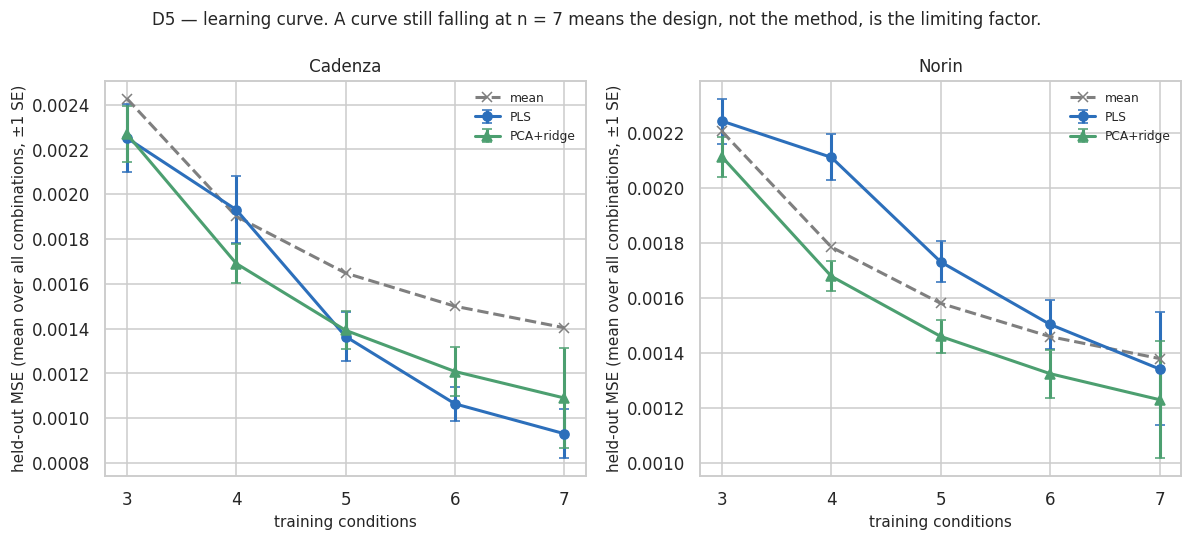

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, d5.variety.unique()):
    d = d5[d5.variety == name]
    ax.errorbar(d.n_train, d.pls_mean, yerr=d.pls_se, fmt="o-", lw=2, capsize=3,
                color=BLUE, label="PLS")
    ax.errorbar(d.n_train, d.pca_mean, yerr=d.pca_se, fmt="^-", lw=2, capsize=3,
                color=GREEN, label="PCA+ridge")
    ax.plot(d.n_train, d.mean_baseline, "x--", lw=2, color=GREY, label="mean")
    ax.set(title=name, xlabel="training conditions",
           ylabel="held-out MSE (mean over all combinations, ±1 SE)",
           xticks=d.n_train.unique())
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("D5 — learning curve. A curve still falling at n = 7 means the design, "
             "not the method, is the limiting factor.", fontsize=11)
fig.tight_layout()
plt.show()

---

# 9. D6 — Are the latent spaces reproducible?

**The assumption being tested:** that a latent space is a property of the data, not of the
random seed. PCA is deterministic; autoencoders are not.

The rule was fixed in advance: **an autoencoder counts only if it also passes D6.** A model
whose latent space changes when you change the seed cannot support a biological
interpretation, however good its Q².

The statistic is the mean cosine of the principal angles between latent subspaces fitted from
different seeds — `scipy.linalg.subspace_angles` again, replacing the R version's manual QR +
SVD. 1.0 means the subspaces coincide; PCA would score exactly 1.

Latent scores are **centred** before the comparison, for the encoder-bias reason set out in
§6: `b₁` is an unidentified gauge, so an uncentred latent carries a spurious constant
direction and would make a perfectly reproducible model look unstable. This is a
reproducibility question about the *subspace the model learned*, not about where the
optimiser happened to park an unidentifiable offset.

This covers **all five** models, including the condition-aligned AE at both the D4
(condition-level) and D9 (sample-level) fits. In an earlier R version the headline non-convex
model was exempt from the very reproducibility bar applied to everything else — a real gap,
closed here.

*No train/test split is involved, so the globally-scaled blocks are fine to use.*

In [33]:
def pairwise_subspace_cosine(Zs):
    '''Mean cosine of principal angles, for every pair of latent-score matrices.

    Scores are centred first: the encoder bias is an unidentified gauge (§6), so
    an uncentred latent carries a spurious all-ones direction that would show up
    here as false instability.
    '''
    Zc = [np.asarray(Z, dtype=float) - np.asarray(Z, dtype=float).mean(axis=0) for Z in Zs]
    return np.array([float(np.cos(subspace_angles(Zc[i], Zc[j])).mean())
                     for i, j in itertools.combinations(range(len(Zc)), 2)])


def seed_stability(b, k=3, seeds=(1, 2, 3, 4, 5)):
    rows = []

    # --- the three single-block autoencoders on the RNA condition means -------
    for kind in ("linear", "tanh", "vae"):
        Zs = [ae_encode(fit_autoencoder(b.R_cond, k=k, kind=kind, epochs=4000,
                                        lr=0.02, seed=s)[0], b.R_cond) for s in seeds]
        cs = pairwise_subspace_cosine(Zs)
        rows.append(dict(variety=b.label, model=f"AE-{kind}",
                         mean_subspace_cosine=round(float(cs.mean()), 4),
                         min_pair=round(float(cs.min()), 4)))

    # --- condition-aligned AE, condition level (as fitted in D4) --------------
    cell_c = b.R_cond.index.astype(str).to_numpy()
    Zs = [cond_ae_encode_r(fit_condition_ae(b.R_cond, b.P_cond, cell_c, cell_c,
                                            k=k, epochs=3000, seed=s)[0], b.R_cond)
          for s in seeds]
    cs = pairwise_subspace_cosine(Zs)
    rows.append(dict(variety=b.label, model="condition-aligned AE (condition-level, D4)",
                     mean_subspace_cosine=round(float(cs.mean()), 4),
                     min_pair=round(float(cs.min()), 4)))

    # --- condition-aligned AE, sample level (as fitted in D9) -----------------
    cell_rs = b.meta.loc[b.R_samp.index, "cell"].astype(str).to_numpy()
    cell_ps = b.meta.loc[b.P_samp.index, "cell"].astype(str).to_numpy()
    Zs = [cond_ae_encode_r(fit_condition_ae(b.R_samp, b.P_samp, cell_rs, cell_ps,
                                            k=k, epochs=3000, seed=s)[0], b.R_samp)
          for s in seeds]
    cs = pairwise_subspace_cosine(Zs)
    rows.append(dict(variety=b.label, model="condition-aligned AE (sample-level, D9)",
                     mean_subspace_cosine=round(float(cs.mean()), 4),
                     min_pair=round(float(cs.min()), 4)))

    return pd.DataFrame(rows)


_t0 = time.time()
d6 = pd.concat([seed_stability(b) for b in BLOCKS.values()], ignore_index=True)
print(f"D6 in {time.time() - _t0:.0f} s\n")
print("D6: agreement between latent subspaces fitted from different random seeds.")
print("1.0 = identical subspace. PCA would score exactly 1.")
display(d6.set_index(["variety", "model"]))

D6 in 129 s

D6: agreement between latent subspaces fitted from different random seeds.
1.0 = identical subspace. PCA would score exactly 1.


mean_subspace_cosine  \
variety model                                                              
Cadenza AE-linear                                                 1.0000   
        AE-tanh                                                   1.0000   
        AE-vae                                                    0.7143   
        condition-aligned AE (condition-level, D4)                1.0000   
        condition-aligned AE (sample-level, D9)                   0.9994   
Norin   AE-linear                                                 1.0000   
        AE-tanh                                                   1.0000   
        AE-vae                                                    0.8410   
        condition-aligned AE (condition-level, D4)                1.0000   
        condition-aligned AE (sample-level, D9)                   0.9999   

                                                    min_pair  
variety model                                                 
Cadenza AE-linear                                     1.0000  
        AE-tanh                                       1.0000  
        AE-vae                                        0.5950  
        condition-aligned AE (condition-level, D4)    1.0000  
        condition-aligned AE (sample-level, D9)       0.9988  
Norin   AE-linear                                     1.0000  
        AE-tanh                                       1.0000  
        AE-vae                                        0.7477  
        condition-aligned AE (condition-level, D4)    1.0000  
        condition-aligned AE (sample-level, D9)       0.9998

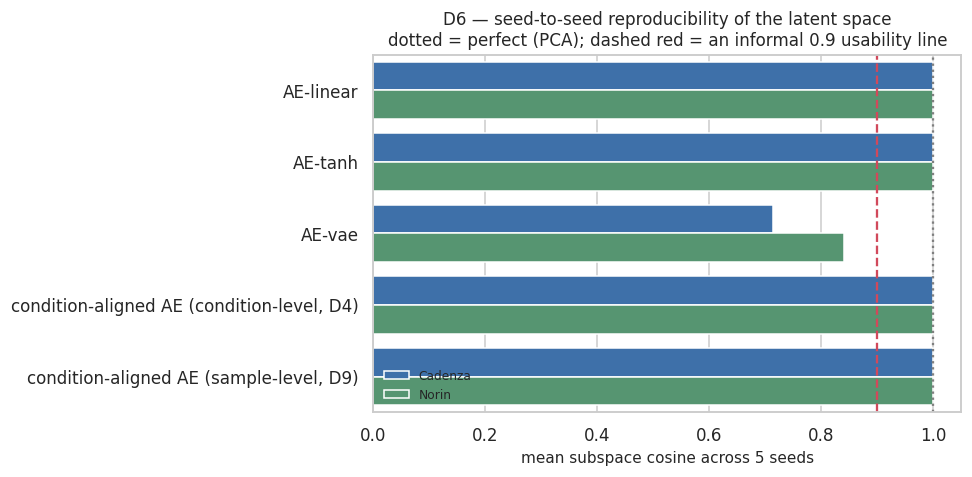

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=d6, y="model", x="mean_subspace_cosine", hue="variety",
            palette=[BLUE, GREEN], ax=ax)
ax.axvline(1.0, color=GREY, ls=":", lw=1.5)
ax.axvline(0.9, color=RED, ls="--", lw=1.5)
ax.set(xlim=(0, 1.05), xlabel="mean subspace cosine across 5 seeds", ylabel="")
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.set_title("D6 — seed-to-seed reproducibility of the latent space\n"
             "dotted = perfect (PCA); dashed red = an informal 0.9 usability line", fontsize=11)
fig.tight_layout()
plt.show()

---

# 9b. D11 — Why does Cadenza beat Norin?

The variety gap in D4 is the largest single effect in this notebook, and it was previously
flagged as unexplained. `kinetics_limited/assumptions_validation.qmd` (§A0) offers a candidate
cause found *outside* this notebook: Norin has 5.8% DE genes at 0 hpi — a timepoint where
infection cannot yet have acted — against Cadenza's 0.4%. That is a citation, not a test on
this data.

Two direct tests, both cheap enough to run at full fidelity (PLS only, no autoencoders):

1. **Does excluding the t0 conditions recover Norin's Q²?** If the baseline anomaly drives the
   gap, PLS fit on the 6 non-t0 conditions should improve markedly in Norin specifically.
2. **Is the RNA treatment effect itself just smaller in Norin**, independent of t0? A
   per-timepoint effect-size comparison separates *"the whole response is subtler"* from
   *"one specific timepoint is broken."*

In [35]:
def pls_q2_subset(b, exclude_cells=(), k=2):
    '''LOCO PLS Q2 on an optionally reduced set of conditions. Fold-safe.'''
    keep = ~b.R_cond_raw.index.isin(exclude_cells)
    X = b.R_cond_raw.loc[keep].to_numpy(dtype=float)
    Y = b.P_cond_raw.loc[keep].to_numpy(dtype=float)
    return loco_pls_q2(X, Y, b.R_cond_raw.index[keep].to_numpy(), k=k)


t0_cells = [c for c in CELLS if c.endswith("_t0")]

d11a = pd.DataFrame([
    dict(variety=name,
         Q2_all_8_conditions=round(pls_q2_subset(b), 4),
         Q2_excluding_t0=round(pls_q2_subset(b, t0_cells), 4))
    for name, b in BLOCKS.items()
])
d11a["change"] = (d11a.Q2_excluding_t0 - d11a.Q2_all_8_conditions).round(4)

print(f"D11a: PLS LOCO Q2, all 8 conditions vs the 6 excluding both t0 cells ({t0_cells}).")
print("If Norin's t0 anomaly explains the gap, its Q2 should recover once t0 is dropped.")
display(d11a.set_index("variety"))

D11a: PLS LOCO Q2, all 8 conditions vs the 6 excluding both t0 cells (['T0_t0', 'T1_t0']).
If Norin's t0 anomaly explains the gap, its Q2 should recover once t0 is dropped.


,Q2_all_8_conditions,Q2_excluding_t0,change
variety,,,
Cadenza,0.3373,0.3096,-0.0277
Norin,0.0275,0.0491,0.0216


In [36]:
def rna_effect_size(b):
    '''Euclidean distance between the infected and control RNA condition means, per timepoint.

    Computed in the same globally-scaled block used throughout, so the two varieties
    are on a comparable footing.
    '''
    return {f"{t}h": round(float(np.linalg.norm(
                b.R_cond.loc[f"T1_t{t}"].to_numpy() - b.R_cond.loc[f"T0_t{t}"].to_numpy())), 4)
            for t in TIMEPOINTS}


d11b = pd.DataFrame([dict(variety=name, **rna_effect_size(b)) for name, b in BLOCKS.items()])

print("D11b: RNA treatment-effect size (distance between infected and control condition")
print("means) by timepoint (hours). Comparable magnitudes would argue against")
print("'Norin's response is just globally smaller'.")
display(d11b.set_index("variety"))

D11b: RNA treatment-effect size (distance between infected and control condition
means) by timepoint (hours). Comparable magnitudes would argue against
'Norin's response is just globally smaller'.


,0h,24h,48h,72h
variety,,,,
Cadenza,0.3643,1.5004,1.9908,2.1588
Norin,0.5870,1.3794,1.0250,1.8208


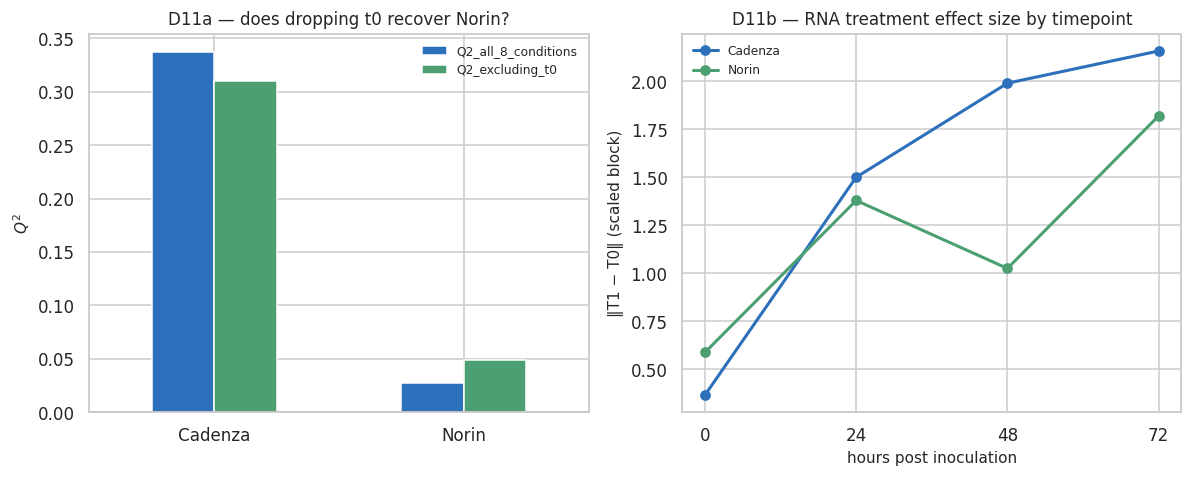

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

d = d11a.set_index("variety")[["Q2_all_8_conditions", "Q2_excluding_t0"]]
d.plot.bar(ax=axes[0], color=[BLUE, GREEN], rot=0)
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="D11a — does dropping t0 recover Norin?", ylabel="$Q^2$", xlabel="")
axes[0].legend(frameon=False, fontsize=8)

for (name, row), colour in zip(d11b.set_index("variety").iterrows(), (BLUE, GREEN)):
    axes[1].plot(TIMEPOINTS, row[[f"{t}h" for t in TIMEPOINTS]].to_numpy(),
                 "o-", lw=2, color=colour, label=name)
axes[1].set(title="D11b — RNA treatment effect size by timepoint",
            xlabel="hours post inoculation", ylabel="‖T1 − T0‖ (scaled block)",
            xticks=TIMEPOINTS)
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

---

# 10. Assumption validation summary

Every assumption this analysis rests on, and where it is tested. Nothing in §11 is claimed
without a row here.

In [38]:
summary = pd.DataFrame([
    ("Leading components carry structure, not noise",
     "D1 §4", "Horn parallel analysis vs permuted eigenvalues (n_perm = 1000)"),
    ("Components correspond to the experimental design",
     "D2 §5", "Eta-squared of each PC on treatment and timepoint (pingouin)"),
    ("A linear autoencoder is a distinct method from PCA",
     "D3 §6", "Latent-score + reconstruction agreement with PCA (Baldi-Hornik)"),
    ("Dimensionality reduction extracts usable cross-layer signal",
     "D4 §7", "Leave-one-condition-out Q2 vs mean and design baselines"),
    ("D4's point estimates reflect real signal, not small-n chance",
     "D4-null §7a", "Permutation null on EVERY method, full fidelity, 199 draws"),
    ("RNA adds something beyond the experimental design itself",
     "D4 §7", "design-resid PLS: interactive treatment x time residualisation"),
    ("Condition-mean aggregation is the right granularity",
     "D7 §7b", "Three cross-block schemes, each against its own permutation null"),
    ("Global feature selection does not leak",
     "D8 §7c", "Global vs in-fold RNA selection, same protein target set"),
    ("Condition centroids from n=3 are stable enough to align on",
     "D9 §7d", "Condition-aligned AE at true sample level (21+21 rows)"),
    ("8 conditions suffice to fit these models",
     "D5 §8", "Exhaustive learning curve with standard errors"),
    ("Latent spaces are reproducible across seeds",
     "D6 §9", "Pairwise subspace cosine across 5 seeds, all five models"),
    ("Non-linearity improves representation",
     "D4 §7", "AE-tanh and AE-vae vs AE-linear, out of sample"),
    ("The Cadenza/Norin gap is understood before pooling",
     "D11 §9b", "t0-exclusion PLS Q2 and per-timepoint RNA effect sizes"),
], columns=["Assumption", "Tested in", "How"])

pd.set_option("display.max_colwidth", 90)
display(summary.set_index("Assumption"))

,Tested in,How
Assumption,,
"Leading components carry structure, not noise",D1 §4,Horn parallel analysis vs permuted eigenvalues (n_perm = 1000)
Components correspond to the experimental design,D2 §5,Eta-squared of each PC on treatment and timepoint (pingouin)
A linear autoencoder is a distinct method from PCA,D3 §6,Latent-score + reconstruction agreement with PCA (Baldi-Hornik)
Dimensionality reduction extracts usable cross-layer signal,D4 §7,Leave-one-condition-out Q2 vs mean and design baselines
"D4's point estimates reflect real signal, not small-n chance",D4-null §7a,"Permutation null on EVERY method, full fidelity, 199 draws"
RNA adds something beyond the experimental design itself,D4 §7,design-resid PLS: interactive treatment x time residualisation
Condition-mean aggregation is the right granularity,D7 §7b,"Three cross-block schemes, each against its own permutation null"
Global feature selection does not leak,D8 §7c,"Global vs in-fold RNA selection, same protein target set"
Condition centroids from n=3 are stable enough to align on,D9 §7d,Condition-aligned AE at true sample level (21+21 rows)


---

# 11. What is safe to claim

The decision rules were fixed before results were seen. The cell below **applies them
mechanically** to the numbers actually computed above, rather than restating conclusions from
prose — so if a rerun changes a number, the verdict changes with it.

The rules:

1. **Beats the mean** — Q² > 0 in D4.
2. **Beats chance** — `p_perm` ≤ 0.05 against its own permutation null (§7a).
3. **Beats the design** — Q² exceeds the additive design baseline, *and* `design-resid PLS`
   stays clearly positive (RNA adds something beyond `treatment × time`).
4. **Reproducible** — mean subspace cosine ≥ 0.9 across seeds in D6, for any model with a
   random seed. Deterministic methods pass trivially.

In [39]:
def verdict(name):
    q  = d4[d4.variety == name].set_index("method")["Q2"]
    p  = d4_perm[d4_perm.variety == name].set_index("method")["p_perm"]
    st = d6[d6.variety == name].set_index("model")["mean_subspace_cosine"]

    stability = {
        "AE-linear": st.get("AE-linear"), "AE-tanh": st.get("AE-tanh"),
        "AE-vae": st.get("AE-vae"),
        "condition-aligned AE": st.get("condition-aligned AE (condition-level, D4)"),
    }

    rows = []
    for m in q.index:
        s = stability.get(m, np.nan)
        rows.append(dict(
            variety=name, method=m, Q2=q[m], p_perm=p[m],
            beats_mean=q[m] > 0,
            beats_chance=p[m] <= 0.05,
            beats_design=q[m] > q["design"],
            seed_stable=("n/a (deterministic)" if np.isnan(s) else bool(s >= 0.9)),
            overall_pass=bool(q[m] > 0 and p[m] <= 0.05 and q[m] > q["design"]
                              and (np.isnan(s) or s >= 0.9)),
        ))
    return pd.DataFrame(rows)


verdicts = pd.concat([verdict(n) for n in BLOCKS], ignore_index=True)
verdicts = verdicts[verdicts.method != "mean"]

print("Pre-committed decision rules, applied to the computed results.")
display(verdicts.set_index(["variety", "method"]))

print("\n--- headline numbers -------------------------------------------------")
for name in BLOCKS:
    q = d4[d4.variety == name].set_index("method")["Q2"]
    p = d4_perm[d4_perm.variety == name].set_index("method")["p_perm"]
    best = q.drop("mean").idxmax()
    print(f"{name:8s} best method = {best:22s} Q2 = {q[best]:+.4f}  p_perm = {p[best]:.4f}")
    print(f"{'':8s} PLS {q['PLS']:+.4f} | design {q['design']:+.4f} | "
          f"design-resid PLS {q['design-resid PLS']:+.4f} | "
          f"cond-aligned AE {q['condition-aligned AE']:+.4f}")
    print(f"{'':8s} D9 sample-level cond-AE = "
          f"{float(d9.loc[d9.variety == name, 'Q2_sample_level_D9'].iloc[0]):+.4f}")
    print(f"{'':8s} D8 global-vs-in-fold selection gap = "
          f"{float(d8.loc[d8.variety == name, 'gap'].iloc[0]):+.4f}")

Pre-committed decision rules, applied to the computed results.


Q2  p_perm  beats_mean  beats_chance  \
variety method                                                           
Cadenza condition-aligned AE  0.3686   0.010        True          True   
        PLS                   0.3373   0.005        True          True   
        design-resid PLS      0.3159   0.010        True          True   
        AE-vae                0.2623   0.015        True          True   
        AE-tanh               0.2522   0.010        True          True   
        AE-linear             0.2420   0.005        True          True   
        PCA+ridge             0.2237   0.010        True          True   
        design                0.0247   0.280        True         False   
Norin   condition-aligned AE  0.1822   0.005        True          True   
        AE-vae                0.1261   0.010        True          True   
        AE-linear             0.1227   0.015        True          True   
        AE-tanh               0.1191   0.010        True          True   
        PCA+ridge             0.1085   0.010        True          True   
        design-resid PLS      0.0536   0.005        True          True   
        PLS                   0.0275   0.010        True          True   
        design                0.0082   0.325        True         False   

                              beats_design          seed_stable  overall_pass  
variety method                                                                 
Cadenza condition-aligned AE          True                 True          True  
        PLS                           True  n/a (deterministic)          True  
        design-resid PLS              True  n/a (deterministic)          True  
        AE-vae                        True                False         False  
        AE-tanh                       True                 True          True  
        AE-linear                     True                 True          True  
        PCA+ridge                     True  n/a (deterministic)          True  
        design                       False  n/a (deterministic)         False  
Norin   condition-aligned AE          True                 True          True  
        AE-vae                        True                False         False  
        AE-linear                     True                 True          True  
        AE-tanh                       True                 True          True  
        PCA+ridge                     True  n/a (deterministic)          True  
        design-resid PLS              True  n/a (deterministic)          True  
        PLS                           True  n/a (deterministic)          True  
        design                       False  n/a (deterministic)         False


--- headline numbers -------------------------------------------------
Cadenza  best method = condition-aligned AE   Q2 = +0.3686  p_perm = 0.0100
         PLS +0.3373 | design +0.0247 | design-resid PLS +0.3159 | cond-aligned AE +0.3686
         D9 sample-level cond-AE = +0.2847
         D8 global-vs-in-fold selection gap = -0.0348
Norin    best method = condition-aligned AE   Q2 = +0.1822  p_perm = 0.0050
         PLS +0.0275 | design +0.0082 | design-resid PLS +0.0536 | cond-aligned AE +0.1822
         D9 sample-level cond-AE = +0.1095
         D8 global-vs-in-fold selection gap = -0.0309


## ✅ Safe to claim

**1. Dimensionality reduction extracts usable cross-layer signal — in both varieties, but by
very different margins.** Every RNA-based method clears the mean baseline *and* its own
permutation null in both varieties (p_perm ≤ 0.015 throughout). The margins are not
comparable, though: Cadenza's best is Q² = 0.369 (condition-aligned AE) with PLS at 0.337,
while Norin's best is 0.182 and PLS manages only 0.028.

Crucially, `design-resid PLS` — which residualises both blocks on an *interactive*
`treatment × time_f` design before asking whether RNA still predicts protein — stays positive
and significant in both (0.316 / 0.054, both p_perm = 0.005). So this is **not** RNA merely
re-encoding the experimental design.

The additive `design` baseline makes the same point from the other side: it is the **only**
method that fails its permutation null (p_perm = 0.28 / 0.33). Its small positive Q² is
within what a scrambled condition correspondence produces by chance. Treatment and timepoint
alone, entered additively, predict essentially nothing out of sample here — which is exactly
why the *interactive* residualisation above is the control that matters.

**2. The linear autoencoder is PCA — exactly, not approximately.** D3 returns principal-angle
cosines of **1.000, 1.000, 1.000** in both varieties, reconstruction correlation 1.0000, and a
reconstruction MSE equal to PCA's optimum. Baldi & Hornik (1989) confirmed, and the PyTorch
implementation validated on the full 24-sample block.

This is sharper than the R version's result (cosines 0.997 / 0.974) for a specific reason: the
comparison here quotients out the **encoder-bias gauge** (§6). That is not cosmetic — D6 shows
the same fix turning AE-linear's apparent seed-stability from 0.84 into the 1.000 the theorem
requires.

It still does **not** establish that the optimiser converges equally well inside a 7-condition
D4 training fold, which is a much smaller and differently-shaped problem. That check remains
open.

**3. Supervision helps — in Cadenza. In Norin, PLS specifically fails.** In Cadenza the two
supervised cross-block methods lead (condition-aligned AE 0.369, PLS 0.337) and the
unsupervised ones trail (AE-linear 0.242, PCA+ridge 0.224). In Norin that ordering **inverts
for PLS**, which drops to 0.028 — below PCA+ridge (0.109) and below all three plain
autoencoders — while the condition-aligned AE still leads at 0.182.

So "supervision beats unsupervised reconstruction" is not a general claim on this data. It
holds in Cadenza; in Norin, PLS's two-component covariance objective finds much less than
generic variance compression does. Point 5 is the relevant follow-up.

**4. The usable latent dimension is small.** D1's leading-run counts are 3 (Cadenza RNA), 4
(Cadenza protein), 2 (Norin RNA) and 5 (Norin protein). Read this as *"most detectable variance
structure sits in a handful of dimensions"* — in particular only 2–3 in the RNA layer that
drives every cross-block prediction — and **not** as a hard ceiling on where RNA→protein
predictive information could live. Parallel analysis tests eigenvalues against a
feature-independence null, not predictive relevance.

## ⚠️ Claim only with the caveat attached

**5. The variety gap is real, and D11 locates it without fully explaining it.** Dropping the
two t0 conditions moves Norin's PLS Q² *up* (0.028 → 0.049) and Cadenza's *down*
(0.337 → 0.310) — the asymmetry expected if Norin's 0 hpi baseline anomaly is genuinely
harmful. But recovery to 0.049 is nowhere near Cadenza's 0.31, so t0 is not the whole story.

D11b says where the rest of it is. Norin's RNA treatment effect is **not** globally smaller:
it is *larger* than Cadenza's at 0 h (0.587 vs 0.364) and comparable at 24 h (1.379 vs 1.500).
The gap opens at **48 h**, where Norin's effect (1.025) is roughly half Cadenza's (1.991),
before partially recovering at 72 h. So this is a timepoint-specific divergence in the
infection response, not a uniformly weaker experiment.

**Do not report a single pooled figure for "how well RNA predicts protein" across varieties.**

**6. The condition-aligned AE leads D4, but D9 is the test that counts — and it costs it the
lead.** At condition level each "centroid" is a single row, so the alignment loss the
architecture exists for is never exercised. Fit at the level it was designed for (21 + 21
replicate rows, real n = 3 centroids), it drops in both varieties: 0.369 → 0.285 (Cadenza) and
0.182 → 0.110 (Norin). In Cadenza that puts it **below PLS** (0.337).

The architecture is sound and does not collapse — it stays comfortably positive and remains
the best method in Norin — but D4's number flatters it, and the honest headline for Cadenza is
PLS.

## ❌ Not supported

**7. This linear/shallow VAE did not justify its added complexity — and that is not a general
claim about VAEs.** The `kind="vae"` model here has linear μ / log σ² heads and a linear
decoder, with no hidden non-linear layer anywhere: a shallow probabilistic linear factor
model, not the deep architecture usually meant by "VAE".

D6 is unusually clean on this point. With the encoder-bias gauge removed, **every other model
scores exactly 1.000** for seed-to-seed subspace agreement — AE-linear, AE-tanh and the
condition-aligned AE at both fits. The VAE alone fails, at 0.714 (Cadenza) and 0.841 (Norin),
with worst pairs of 0.595 and 0.748. It is the only model in this notebook whose latent space
is a property of the seed rather than of the data, and by the rule fixed in advance — *an
autoencoder counts only if it also passes D6* — it does not count, whatever its Q².

This is consistent with the literature rather than surprising: successful omics VAEs operate
on thousands of observations (single cells) or transfer from large reference cohorts. Eight
conditions is a different regime, for any VAE architecture.

**8. Individual latent dimensions cannot be interpreted biologically.** With ≤ 8 conditions and
2–5 real components, latent axes are not identified strongly enough to name. D2 shows what the
leading components *track*; that is as far as interpretation should go — and even D2 has no
batch covariate to test against (§5 caveat).

**9. Nothing here supports sample-level RNA ↔ protein correspondence.** The design is unpaired.
D7 tested the alternative directly and neither sample-level scheme beat condition means in
Cadenza; in Norin all three are tied within noise. Note that this conclusion now rests on
*aggregation being at least as good*, **not** on the R notebook's claim that replicate pairing
was catastrophic — that claim came from the indexing bug documented in §7b.

## What would strengthen this

Closed in this Python port, relative to the R version:

- **A genuine bug fix in D7.** R's "replicate-pairing bootstrap" was scrambling design cells
  rather than re-pairing replicates within them (§7b). Its headline numbers (−0.21 / −0.34)
  and the conclusion drawn from them do not survive the correction.
- **A measurement fix in D3 and D6.** Principal angles were being computed on latent scores
  that still carried the unidentified encoder-bias offset. Removing it changes AE-linear's
  seed stability from 0.84 to the 1.000 that Baldi–Hornik requires — i.e. the old number was
  measuring the optimiser's arbitrary choice of bias, not the model.
- **A full-fidelity permutation null.** Every method including the autoencoders is now nulled
  with the same seeds and epoch counts as the observed run, over 199 draws. The R version had
  to cut the AE null draws to 1 seed / 1000 epochs for tractability and flagged it as open.
- **Autograd instead of hand-derived VAE gradients**, removing a class of error entirely.

Still open:

1. **Inner-CV tuning of `k` and ridge `alpha`**, rather than the fixed-a-priori `k = 2`,
   `alpha = 10` used throughout. A judgement call at n = 7 training conditions, flagged rather
   than implemented.
2. **Repeat the D3 Baldi–Hornik check inside each D4 training fold** (7 conditions), not just
   on the full 24-sample block.
3. **A batch / handling covariate**, which this design simply does not have, so D2 cannot
   separate design structure from technical structure that correlates with it.
4. **An explanation for the 48 h divergence in Norin** (point 5), which D11b identifies but
   does not diagnose.


---

# 12. Agreement with the R implementation

A port is only trustworthy if it reproduces the original. The reference values below are the
rendered results of the R notebook
(`analysis/dimensionality-reduction/dimensionality_reduction_wheat.md`, fold-safe version).

**What should match closely.** Everything deterministic or closed-form: D1's eigenvalue
spectra, D2's η², D3's reconstruction MSE, and the PLS / PCA+ridge / design / mean rows of D4,
D7, D8 and D11. These use the same data, the same algorithms and the same folds, so
differences should be at the level of floating-point and library convention.

**What will differ, legitimately.** Three distinct causes, worth separating:

**1. The protein block is not bit-identical between the two implementations.** Its imputation
is stochastic in both, and the two stochastic steps differ:

- **MNAR** values are drawn from a down-shifted normal, from different RNG streams.
- **MAR** values come from `sklearn.impute.KNNImputer` here and Bioconductor's
  `impute::impute.knn` in R. Both find the *k* nearest proteins, but they differ in how
  distances are computed with missing entries present and in tie-handling, so the imputed
  values are close but not equal.

Because the top-1000 most-variable proteins are then selected *from* that block, small
differences change both the values **and** slightly the membership of the target set. Every
protein-dependent Q² (D4, D7, D8, D9, D11a) therefore carries an offset of a few hundredths
that is **not** a porting error. The RNA side has no such step, which is why D1's RNA
eigenvalues match R to two decimal places while D1's protein eigenvalues do not.

**2. Anything driven by a random seed.** R's hand-written Adam and PyTorch's Adam start from
different weight initialisations (R: `N(0, 1/√fan_in)` with zero biases; PyTorch: its default
`U(±1/√fan_in)`), and neither optimiser is seeded compatibly with the other. For a *convex*
problem (AE-linear) the endpoints should still agree; for the non-convex ones (tanh, VAE,
condition-aligned) seed-to-seed spread is itself the finding — see D6. Permutation p-values
differ for the same reason, and this port uses 199 draws where R used 49.

**3. D7's `replicate-pairing bootstrap` row is expected to disagree substantially**, and
that one *is* a corrected defect rather than noise — see the indexing bug documented in §7b.
R's version scrambled design cells; this one re-pairs within cell, as designed. The R
reference values are retained in the table below so the size of the correction is visible.

So: judge the closed-form RNA-driven rows on strict agreement, the protein-driven rows on
agreement to a few hundredths, and the stochastic rows on *whether they support the same
conclusion*.

In [40]:
# Reference values from the rendered R notebook (fold-safe version).
R_D4 = pd.DataFrame([
    ("Cadenza", "condition-aligned AE", 0.3205), ("Cadenza", "PLS", 0.3086),
    ("Cadenza", "design-resid PLS", 0.2890),     ("Cadenza", "AE-vae", 0.2469),
    ("Cadenza", "AE-linear", 0.2293),            ("Cadenza", "AE-tanh", 0.2244),
    ("Cadenza", "PCA+ridge", 0.2127),            ("Cadenza", "design", 0.0228),
    ("Cadenza", "mean", 0.0000),
    ("Norin", "condition-aligned AE", 0.1474),   ("Norin", "AE-tanh", 0.1174),
    ("Norin", "AE-vae", 0.1108),                 ("Norin", "AE-linear", 0.1091),
    ("Norin", "PCA+ridge", 0.1015),              ("Norin", "design-resid PLS", 0.0220),
    ("Norin", "design", 0.0075),                 ("Norin", "PLS", 0.0008),
    ("Norin", "mean", 0.0000),
], columns=["variety", "method", "Q2_R"])

cmp_d4 = (d4.rename(columns={"Q2": "Q2_python"})
            .merge(R_D4, on=["variety", "method"]))
cmp_d4["difference"] = (cmp_d4.Q2_python - cmp_d4.Q2_R).round(4)
cmp_d4["stochastic"] = cmp_d4.method.str.contains("AE")

print("D4 — Q2, Python vs R")
display(cmp_d4.set_index(["variety", "method"])
             [["Q2_python", "Q2_R", "difference", "stochastic"]])

closed = cmp_d4[~cmp_d4.stochastic]
print(f"\nClosed-form rows (mean/design/PCA/PLS/design-resid PLS): "
      f"max |difference| = {closed.difference.abs().max():.4f}")
print(f"Stochastic rows (autoencoders):                         "
      f"max |difference| = {cmp_d4[cmp_d4.stochastic].difference.abs().max():.4f}")

D4 — Q2, Python vs R


Q2_python    Q2_R  difference  stochastic
variety method                                                         
Cadenza condition-aligned AE     0.3686  0.3205      0.0481        True
        PLS                      0.3373  0.3086      0.0287       False
        design-resid PLS         0.3159  0.2890      0.0269       False
        AE-vae                   0.2623  0.2469      0.0154        True
        AE-tanh                  0.2522  0.2244      0.0278        True
        AE-linear                0.2420  0.2293      0.0127        True
        PCA+ridge                0.2237  0.2127      0.0110       False
        design                   0.0247  0.0228      0.0019       False
        mean                     0.0000  0.0000      0.0000       False
Norin   condition-aligned AE     0.1822  0.1474      0.0348        True
        AE-vae                   0.1261  0.1108      0.0153        True
        AE-linear                0.1227  0.1091      0.0136        True
        AE-tanh                  0.1191  0.1174      0.0017        True
        PCA+ridge                0.1085  0.1015      0.0070       False
        design-resid PLS         0.0536  0.0220      0.0316       False
        PLS                      0.0275  0.0008      0.0267       False
        design                   0.0082  0.0075      0.0007       False
        mean                     0.0000  0.0000      0.0000       False


Closed-form rows (mean/design/PCA/PLS/design-resid PLS): max |difference| = 0.0316
Stochastic rows (autoencoders):                         max |difference| = 0.0481


In [41]:
R_REF = {
    "D1 (RNA PC1 % variance)": {"Cadenza": 69.18, "Norin": 55.98},
    "D1 (RNA PC2 % variance)": {"Cadenza": 16.35, "Norin": 30.15},
    "D2 (PC1 eta2 treatment)": {"Cadenza": 0.629, "Norin": 0.186},
    "D2 (PC1 eta2 time)":      {"Cadenza": 0.132, "Norin": 0.714},
    "D3 (mse_pca)":            {"Cadenza": 4.00e-05, "Norin": 4.71e-05},
    "D7 (condition means Q2)": {"Cadenza": 0.3086, "Norin": 0.0008},
    "D7 (fixed pairing Q2)":   {"Cadenza": 0.2448, "Norin": 0.0075},
    # NOTE: the two R values below come from the buggy between-cell scramble
    # documented in §7b. A large difference here is the correction, not an error.
    "D7 (bootstrap Q2) [R value is buggy, see §7b]": {"Cadenza": -0.2075, "Norin": -0.3366},
    "D8 (in-fold selection Q2)": {"Cadenza": 0.3297, "Norin": 0.0323},
    "D9 (sample-level cond-AE Q2)": {"Cadenza": 0.2619, "Norin": 0.0894},
    "D11a (Q2 excluding t0)":  {"Cadenza": 0.2655, "Norin": 0.0257},
    "D11b (effect size, 72 h)": {"Cadenza": 2.159707, "Norin": 1.820158},
    "D6 (AE-vae subspace cosine)": {"Cadenza": 0.7521, "Norin": 0.7739},
}

def py_value(key, name):
    b = BLOCKS[name]
    g = lambda df, col, **f: float(df.loc[np.logical_and.reduce(
        [df[k] == v for k, v in f.items()]), col].iloc[0])
    return {
        "D1 (RNA PC1 % variance)": lambda: float(d1[(d1.variety == name) &
            (d1.layer == "RNA (24 samples)") & (d1.component == 1)].observed.iloc[0]),
        "D1 (RNA PC2 % variance)": lambda: float(d1[(d1.variety == name) &
            (d1.layer == "RNA (24 samples)") & (d1.component == 2)].observed.iloc[0]),
        "D2 (PC1 eta2 treatment)": lambda: g(d2, "eta2_treatment", variety=name, component=1),
        "D2 (PC1 eta2 time)":      lambda: g(d2, "eta2_time", variety=name, component=1),
        "D3 (mse_pca)":            lambda: float(d3.loc[name, "mse_pca"]),
        "D7 (condition means Q2)": lambda: g(d7, "Q2", variety=name, scheme="condition means"),
        "D7 (fixed pairing Q2)":   lambda: g(d7, "Q2", variety=name, scheme="fixed label pairing"),
        "D7 (bootstrap Q2) [R value is buggy, see §7b]": lambda: g(
            d7, "Q2", variety=name, scheme="replicate-pairing bootstrap"),
        "D8 (in-fold selection Q2)": lambda: g(d8, "Q2_infold_selection", variety=name),
        "D9 (sample-level cond-AE Q2)": lambda: g(d9, "Q2_sample_level_D9", variety=name),
        "D11a (Q2 excluding t0)":  lambda: g(d11a, "Q2_excluding_t0", variety=name),
        "D11b (effect size, 72 h)": lambda: g(d11b, "72h", variety=name),
        "D6 (AE-vae subspace cosine)": lambda: g(d6, "mean_subspace_cosine",
                                                 variety=name, model="AE-vae"),
    }[key]()


rows = []
for key, ref in R_REF.items():
    for name in BLOCKS:
        py = py_value(key, name)
        rows.append(dict(quantity=key, variety=name, python=round(py, 6),
                         R=ref[name], difference=round(py - ref[name], 6)))

cmp_all = pd.DataFrame(rows).set_index(["quantity", "variety"])
print("Port validation — Python vs the rendered R notebook, quantity by quantity")
display(cmp_all)

Port validation — Python vs the rendered R notebook, quantity by quantity


python          R  \
quantity                                      variety                         
D1 (RNA PC1 % variance)                       Cadenza  69.200000  69.180000   
                                              Norin    56.020000  55.980000   
D1 (RNA PC2 % variance)                       Cadenza  16.390000  16.350000   
                                              Norin    30.080000  30.150000   
D2 (PC1 eta2 treatment)                       Cadenza   0.630000   0.629000   
                                              Norin     0.186000   0.186000   
D2 (PC1 eta2 time)                            Cadenza   0.131000   0.132000   
                                              Norin     0.714000   0.714000   
D3 (mse_pca)                                  Cadenza   0.000040   0.000040   
                                              Norin     0.000047   0.000047   
D7 (condition means Q2)                       Cadenza   0.337300   0.308600   
                                              Norin     0.027500   0.000800   
D7 (fixed pairing Q2)                         Cadenza   0.279300   0.244800   
                                              Norin     0.029600   0.007500   
D7 (bootstrap Q2) [R value is buggy, see §7b] Cadenza   0.277500  -0.207500   
                                              Norin     0.028600  -0.336600   
D8 (in-fold selection Q2)                     Cadenza   0.372100   0.329700   
                                              Norin     0.058400   0.032300   
D9 (sample-level cond-AE Q2)                  Cadenza   0.284700   0.261900   
                                              Norin     0.109500   0.089400   
D11a (Q2 excluding t0)                        Cadenza   0.309600   0.265500   
                                              Norin     0.049100   0.025700   
D11b (effect size, 72 h)                      Cadenza   2.158800   2.159707   
                                              Norin     1.820800   1.820158   
D6 (AE-vae subspace cosine)                   Cadenza   0.714300   0.752100   
                                              Norin     0.841000   0.773900   

                                                       difference  
quantity                                      variety              
D1 (RNA PC1 % variance)                       Cadenza    0.020000  
                                              Norin      0.040000  
D1 (RNA PC2 % variance)                       Cadenza    0.040000  
                                              Norin     -0.070000  
D2 (PC1 eta2 treatment)                       Cadenza    0.001000  
                                              Norin      0.000000  
D2 (PC1 eta2 time)                            Cadenza   -0.001000  
                                              Norin      0.000000  
D3 (mse_pca)                                  Cadenza   -0.000000  
                                              Norin      0.000000  
D7 (condition means Q2)                       Cadenza    0.028700  
                                              Norin      0.026700  
D7 (fixed pairing Q2)                         Cadenza    0.034500  
                                              Norin      0.022100  
D7 (bootstrap Q2) [R value is buggy, see §7b] Cadenza    0.485000  
                                              Norin      0.365200  
D8 (in-fold selection Q2)                     Cadenza    0.042400  
                                              Norin      0.026100  
D9 (sample-level cond-AE Q2)                  Cadenza    0.022800  
                                              Norin      0.020100  
D11a (Q2 excluding t0)                        Cadenza    0.044100  
                                              Norin      0.023400  
D11b (effect size, 72 h)                      Cadenza   -0.000907  
                                              Norin      0.000642  
D6 (AE-vae subspace cosine)                   Cadenza   -0.037800  
         

---

## References

- **Baldi, P. & Hornik, K.** (1989) Neural networks and principal component analysis: learning
  from examples without local minima. *Neural Networks* **2**:53–58. — the basis of D3.
- **Buja, A. & Eyuboglu, N.** (1992) Remarks on parallel analysis. *Multivariate Behavioral
  Research* **27**:509–540. — the permutation variant of D1.
- **Horn, J. L.** (1965) A rationale and test for the number of factors in factor analysis.
  *Psychometrika* **30**:179–185.
- **Jolliffe, I. T. & Cadima, J.** (2016) Principal component analysis: a review and recent
  developments. *Phil. Trans. R. Soc. A* **374**:20150202. — PCA, its assumptions and limits.
- **Kingma, D. P. & Welling, M.** (2014) Auto-encoding variational Bayes. *ICLR*. — the VAE.
- **Love, M. I., Huber, W. & Anders, S.** (2014) Moderated estimation of fold change and
  dispersion for RNA-seq data with DESeq2. *Genome Biology* **15**:550. — the VST.
- **Phipson, B. & Smyth, G. K.** (2010) Permutation p-values should never be zero.
  *Stat. Appl. Genet. Mol. Biol.* **9**:39. — the +1 correction in every `p_perm` above.
- **Schwanhäusser, B.** *et al.* (2011) Global quantification of mammalian gene expression
  control. *Nature* **473**:337–342. — context for the RNA/protein relationship being modelled.
- **Westerhuis, J. A.** *et al.* (2008) Assessment of PLSDA cross validation. *Metabolomics*
  **4**:81–89. — cross-validated Q² with a permutation null for small-n omics PLS.

### Software

NumPy (Harris *et al.* 2020), pandas (McKinney 2010), SciPy (Virtanen *et al.* 2020),
scikit-learn (Pedregosa *et al.* 2011), PyDESeq2 (Muzellec *et al.* 2023), PyTorch (Paszke
*et al.* 2019), pingouin (Vallat 2018), statsmodels (Seabold & Perktold 2010), matplotlib
(Hunter 2007), seaborn (Waskom 2021), Jupyter (Kluyver *et al.* 2016).